In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pybaseball import statcast

from scipy.stats import ttest_ind, chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

print("Everything imported successfully!")

Everything imported successfully!


In [2]:
from pybaseball import statcast

test_data = statcast(
    start_dt="2024-09-01",
    end_dt="2024-09-02"
)

print(f"Downloaded {len(test_data):,} pitches")

This is a large query, it may take a moment to complete


100%|██████████| 2/2 [00:01<00:00,  1.85it/s]

Downloaded 7,876 pitches


In [3]:
from pathlib import Path

Path("data/raw").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("figures").mkdir(parents=True, exist_ok=True)
Path("results").mkdir(parents=True, exist_ok=True)

test_data.to_csv(
    "data/raw/statcast_test.csv",
    index=False
)

print("Test data saved.")

Test data saved.


In [4]:
from pathlib import Path
from datetime import datetime, timedelta
from pybaseball import statcast
import time

# Project dates
START_DATE = "2021-04-01"
END_DATE = "2025-10-01"

# Create raw data directory
raw_dir = Path("data/raw")
raw_dir.mkdir(parents=True, exist_ok=True)

print(f"Collecting Statcast data from {START_DATE} to {END_DATE}")
print(f"Saving files to: {raw_dir}")

Saving files to: data\raw


In [5]:
start = datetime.strptime(START_DATE, "%Y-%m-%d")
end = datetime.strptime(END_DATE, "%Y-%m-%d")

current_date = start
downloaded = 0
skipped = 0
failed = []

while current_date < end:
    
    date_string = current_date.strftime("%Y-%m-%d")
    next_date = current_date + timedelta(days=1)
    next_date_string = next_date.strftime("%Y-%m-%d")
    
    output_file = raw_dir / f"statcast_{date_string}.csv"
    
    # Don't download a file that already exists
    if output_file.exists():
        skipped += 1
        current_date = next_date
        continue
    
    print(f"Downloading {date_string}...", end=" ")
    
    try:
        daily_data = statcast(
            start_dt=date_string,
            end_dt=next_date_string
        )
        
        daily_data.to_csv(
            output_file,
            index=False
        )
        
        print(f"{len(daily_data):,} pitches")
        downloaded += 1
        
    except Exception as e:
        print("FAILED")
        failed.append((date_string, str(e)))
    
    current_date = next_date
    
    # Give Baseball Savant a short break
    time.sleep(1)

print("\nDownload complete.")
print(f"New files downloaded: {downloaded}")
print(f"Files already present: {skipped}")
print(f"Failed dates: {len(failed)}")

100%|██████████| 2/2 [00:08<00:00,  4.00s/it]


8,488 pitches


100%|██████████| 2/2 [00:03<00:00,  1.55s/it]


5,709 pitches


100%|██████████| 2/2 [00:07<00:00,  3.84s/it]


...

4,460 pitches


100%|██████████| 2/2 [00:00<00:00,  2.90it/s]


1,139 pitches


100%|██████████| 2/2 [00:00<00:00,  2.67it/s]


2,340 pitches

Download complete.
New files downloaded: 71
Files already present: 1573
Failed dates: 0


In [6]:
raw_files = list(raw_dir.glob("statcast_*.csv"))

print(f"Total daily files: {len(raw_files)}")
total_rows = 0

for file in raw_files:
    total_rows += sum(1 for _ in open(file, encoding="utf-8")) - 1

print(f"Total Statcast pitches: {total_rows:,}")

Total daily files: 1645
Total Statcast pitches: 7,585,879


In [7]:
extra_dir = Path("data/extra_innings")
extra_dir.mkdir(parents=True, exist_ok=True)

for i, file in enumerate(raw_files, start=1):

    output_file = extra_dir / file.name

    # Skip files we've already processed
    if output_file.exists():
        continue

    try:

        df = pd.read_csv(
            file,
            usecols=lambda col: col in columns_needed,
            low_memory=True
        )

        # Keep only extra innings
        df = df[
            df["inning"] >= 10
        ].copy()

        # Save immediately
        if len(df) > 0:
            df.to_csv(
                output_file,
                index=False
            )

        del df

        if i % 100 == 0:
            print(
                f"Processed {i:,}/{len(raw_files):,}"
            )

    except Exception as e:
        print(
            f"Error processing {file.name}: {e}"
        )

print("Extra-inning extraction complete.")

Error processing statcast_2021-04-02.csv: name 'columns_needed' is not defined
Error processing statcast_2021-04-03.csv: name 'columns_needed' is not defined
Error processing statcast_2021-04-04.csv: name 'columns_needed' is not defined
Error processing statcast_2021-04-19.csv: name 'columns_needed' is not defined
Error processing statcast_2021-05-16.csv: name 'columns_needed' is not defined
Error processing statcast_2021-06-02.csv: name 'columns_needed' is not defined
Error processing statcast_2021-06-03.csv: name 'columns_needed' is not defined
Error processing statcast_2021-06-07.csv: name 'columns_needed' is not defined
Error processing statcast_2021-06-13.csv: name 'columns_needed' is not defined
Error processing statcast_2021-06-28.csv: name 'columns_needed' is not defined
Error processing statcast_2021-07-07.csv: name 'columns_needed' is not defined
Error processing statcast_2021-07-08.csv: name 'columns_needed' is not defined
Error processing statcast_2021-07-12.csv: name 'colu

In [8]:
columns_needed = [
    # Game information
    "game_date",
    "game_pk",
    "home_team",
    "away_team",
    
    # Inning information
    "inning",
    "inning_topbot",
    "outs_when_up",
    "at_bat_number",
    "pitch_number",
    
    # Player information
    "batter",
    "pitcher",
    
    # Base runners BEFORE the pitch
    "on_1b",
    "on_2b",
    "on_3b",
    
    # Plate appearance outcome
    "events",
    "description",
    
    # Score
    "bat_score",
    "post_bat_score",
    "home_score",
    "away_score",
    
    # Batter / pitcher context
    "stand",
    "p_throws",
    
    # Contact information
    "launch_speed",
    "launch_angle",
    "bb_type",
    
    # Useful Statcast variables
    "delta_run_exp",
    "estimated_ba_using_speedangle",
    "estimated_woba_using_speedangle",
    
    # Pitch information
    "pitch_type",
    "release_speed",
    "release_spin_rate",
    
    # Runner information when available
    "runners"
]

In [9]:
qualifying_situations = []

extra_files = sorted(
    extra_dir.glob("statcast_*.csv")
)

print(
    f"Extra-inning files: {len(extra_files):,}"
)
for i, file in enumerate(extra_files, start=1):

    df = pd.read_csv(
        file,
        low_memory=True
    )

    qualifying = df[
        (df["outs_when_up"] == 0) &
        (df["on_2b"].notna())
    ].copy()

    if len(qualifying) > 0:
        qualifying_situations.append(
            qualifying
        )

    del df

    if i % 100 == 0:
        print(
            f"Checked {i:,}/{len(extra_files):,}"
        )

Extra-inning files: 371
Checked 100/371
Checked 200/371
Checked 300/371


In [10]:
qualifying_data = pd.concat(
    qualifying_situations,
    ignore_index=True
)

print(
    f"Qualifying pitches: "
    f"{len(qualifying_data):,}"
)

Qualifying pitches: 12,181


In [11]:
qualifying_data["half_inning_id"] = (
    qualifying_data["game_pk"].astype(str)
    + "_"
    + qualifying_data["inning"].astype(str)
    + "_"
    + qualifying_data["inning_topbot"].astype(str)
)
qualifying_half_innings = (
    qualifying_data["half_inning_id"]
    .unique()
)

print(
    f"Qualifying half-innings: "
    f"{len(qualifying_half_innings):,}"
)

Qualifying half-innings: 1,332


In [12]:
analysis_parts = []

for i, file in enumerate(extra_files, start=1):

    df = pd.read_csv(
        file,
        low_memory=True
    )

    df["half_inning_id"] = (
        df["game_pk"].astype(str)
        + "_"
        + df["inning"].astype(str)
        + "_"
        + df["inning_topbot"].astype(str)
    )

    relevant = df[
        df["half_inning_id"].isin(
            qualifying_half_innings
        )
    ].copy()

    if len(relevant) > 0:
        analysis_parts.append(relevant)

    del df

    if i % 100 == 0:
        print(
            f"Retrieved {i:,}/{len(extra_files):,}"
        )

Retrieved 100/371
Retrieved 200/371
Retrieved 300/371


In [13]:
import pandas as pd
import numpy as np
from pathlib import Path

# Project folders
raw_dir = Path("data/raw")
extra_dir = Path("data/extra_innings")
processed_dir = Path("data/processed")

extra_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)

# Find raw Statcast files
raw_files = sorted(raw_dir.glob("statcast_*.csv"))

print(f"Found {len(raw_files):,} raw files")

Found 1,645 raw files


In [14]:
columns_needed = [
    # Game information
    "game_date",
    "game_pk",
    "home_team",
    "away_team",
    
    # Inning information
    "inning",
    "inning_topbot",
    "outs_when_up",
    "at_bat_number",
    "pitch_number",
    
    # Player information
    "batter",
    "pitcher",
    
    # Base runners BEFORE the pitch
    "on_1b",
    "on_2b",
    "on_3b",
    
    # Plate appearance outcome
    "events",
    "description",
    
    # Score
    "bat_score",
    "post_bat_score",
    "home_score",
    "away_score",
    
    # Batter / pitcher context
    "stand",
    "p_throws",
    
    # Contact information
    "launch_speed",
    "launch_angle",
    "bb_type",
    
    # Useful Statcast variables
    "delta_run_exp",
    "estimated_ba_using_speedangle",
    "estimated_woba_using_speedangle",
    
    # Pitch information
    "pitch_type",
    "release_speed",
    "release_spin_rate",
    
    # Runner information when available
    "runners"
]

print(f"Columns requested: {len(columns_needed)}")

Columns requested: 32


In [15]:
for i, file in enumerate(raw_files, start=1):

    output_file = extra_dir / file.name

    # Don't redo files we've already processed
    if output_file.exists():
        continue

    try:
        # Get column names without loading the dataset
        available_columns = pd.read_csv(
            file,
            nrows=0
        ).columns.tolist()

        use_columns = [
            col for col in columns_needed
            if col in available_columns
        ]

        df = pd.read_csv(
            file,
            usecols=use_columns,
            low_memory=True
        )

        # Extra innings only
        df = df[
            df["inning"] >= 10
        ].copy()

        if not df.empty:
            df.to_csv(
                output_file,
                index=False
            )

        del df

        if i % 100 == 0:
            print(
                f"Processed {i:,}/{len(raw_files):,}"
            )

    except Exception as e:
        print(
            f"ERROR: {file.name}: {e}"
        )

print("Finished.")

Processed 200/1,645
ERROR: statcast_2021-11-16.csv: No columns to parse from file
ERROR: statcast_2021-11-17.csv: No columns to parse from file
ERROR: statcast_2021-11-18.csv: No columns to parse from file
ERROR: statcast_2021-11-19.csv: No columns to parse from file
ERROR: statcast_2021-11-20.csv: No columns to parse from file
ERROR: statcast_2021-11-21.csv: No columns to parse from file
ERROR: statcast_2021-11-22.csv: No columns to parse from file
ERROR: statcast_2021-11-23.csv: No columns to parse from file
ERROR: statcast_2021-11-24.csv: No columns to parse from file
ERROR: statcast_2021-11-25.csv: No columns to parse from file
ERROR: statcast_2021-11-26.csv: No columns to parse from file
ERROR: statcast_2021-11-27.csv: No columns to parse from file
ERROR: statcast_2021-11-28.csv: No columns to parse from file
ERROR: statcast_2021-11-29.csv: No columns to parse from file
ERROR: statcast_2021-11-30.csv: No columns to parse from file
ERROR: statcast_2021-12-01.csv: No columns to pars

In [16]:
extra_files = sorted(
    extra_dir.glob("statcast_*.csv")
)

print(
    f"Extra-inning files: "
    f"{len(extra_files):,}"
)

Extra-inning files: 848


In [17]:
test_df = pd.read_csv(
    extra_files[23],
    low_memory=True
)

print(test_df.shape)
print(test_df["inning"].min())
print(test_df["inning"].max())

(35, 23)
10
10


In [18]:
qualifying_parts = []

for i, file in enumerate(extra_files, start=1):

    df = pd.read_csv(
        file,
        low_memory=True
    )

    qualifying = df.copy()

    if not qualifying.empty:
        qualifying_parts.append(
            qualifying
        )

    del df

    if i % 100 == 0:
        print(
            f"Checked {i:,}/{len(extra_files):,}"
        )

qualifying_data = pd.concat(
    qualifying_parts,
    ignore_index=True
)

print(
    f"Qualifying pitches: "
    f"{len(qualifying_data):,}"
)

Checked 100/848
Checked 200/848
Checked 300/848
Checked 400/848
Checked 500/848
Checked 600/848
Checked 700/848
Checked 800/848
Qualifying pitches: 91,757


In [19]:
qualifying_data["half_inning_id"] = (
    qualifying_data["game_pk"].astype(str)
    + "_"
    + qualifying_data["inning"].astype(str)
    + "_"
    + qualifying_data["inning_topbot"].astype(str)
)
qualifying_half_innings = (
    qualifying_data["half_inning_id"]
    .unique()
)

print(
    f"Qualifying half-innings: "
    f"{len(qualifying_half_innings):,}"
)

Qualifying half-innings: 3,016


In [20]:
qualifying_data["inning_topbot"].value_counts()

inning_topbot
Top    50482
Bot    41275
Name: count, dtype: int64

In [21]:
analysis_data = pd.concat(
    analysis_parts,
    ignore_index=True
)

print(
    f"Analysis pitches: "
    f"{len(analysis_data):,}"
)
analysis_data.to_csv(
    processed_dir / "extra_inning_analysis_data.csv",
    index=False
)

print("Saved analysis dataset.")

Analysis pitches: 40,827
Saved analysis dataset.


In [22]:
extra = analysis_data[
    analysis_data["inning"] >= 10
].copy()

print(
    f"Extra-inning pitches: {len(extra):,}"
)

Extra-inning pitches: 40,827


In [23]:
extra["half_inning_id"] = (
    extra["game_pk"].astype(str)
    + "_"
    + extra["inning"].astype(str)
    + "_"
    + extra["inning_topbot"].astype(str)
)

In [24]:
# Half-innings that qualify for our study
qualifying_half_innings = first_pa["half_inning_id"].unique()

print(
    f"Qualifying half-innings: "
    f"{len(qualifying_half_innings):,}"
)

NameError: name 'first_pa' is not defined

In [25]:
analysis_data["half_inning_id"] = (
    analysis_data["game_pk"].astype(str)
    + "_"
    + analysis_data["inning"].astype(str)
    + "_"
    + analysis_data["inning_topbot"].astype(str)
)
analysis_data = analysis_data[
    analysis_data["half_inning_id"].isin(
        qualifying_half_innings
    )
].copy()

In [26]:
strategy_data.to_csv(
    "data/processed/extra_innings_strategy.csv",
    index=False
)

strategy_summary.to_csv(
    "results/strategy_summary.csv",
    index=False
)

home_away_summary.to_csv(
    "results/home_away_strategy.csv",
    index=False
)

print("Analysis datasets saved.")

NameError: name 'strategy_data' is not defined

In [27]:
extra_start = extra[
    (extra["inning"] >= 10) &
    (extra["outs_when_up"] == 0) &
    (extra["on_2b"].notna())
].copy()
print(extra_start.shape)

(12181, 32)


In [28]:
display(extra_start[[
    "game_pk",
    "inning",
    "inning_topbot",
    "outs_when_up",
    "on_2b",
    "home_score",
    "away_score",
    "at_bat_number"
]].head(20))

,game_pk,inning,inning_topbot,outs_when_up,on_2b,home_score,away_score,at_bat_number
8,634642,10,Bot,0,592450.0,2,3,78
9,634642,10,Bot,0,592450.0,2,3,78
10,634642,10,Bot,0,592450.0,2,3,78
20,634642,10,Top,0,545341.0,2,3,75
21,634642,10,Top,0,545341.0,2,3,75
22,634642,10,Top,0,545341.0,2,3,75
23,634642,10,Top,0,545341.0,2,3,75
24,634642,10,Top,0,641505.0,2,2,74
25,634642,10,Top,0,641505.0,2,2,74
27,634638,10,Bot,0,456715.0,5,5,90


In [29]:
extra_start = extra[
    (extra["inning"] >= 10) &
    (extra["outs_when_up"] == 0) &
    (extra["on_2b"].notna())
].copy()

extra_start = (
    extra_start
    .sort_values(["game_pk", "inning", "inning_topbot", "at_bat_number", "pitch_number"])
    .groupby(["game_pk", "inning", "inning_topbot"], as_index=False)
    .first()
)

In [30]:
print(extra_start.shape)

(1332, 32)


In [31]:
extra_start[[
    "game_pk",
    "inning",
    "inning_topbot",
    "home_score",
    "away_score",
    "on_2b",
    "outs_when_up",
    "at_bat_number"
]].head(20)

,game_pk,inning,inning_topbot,home_score,away_score,on_2b,outs_when_up,at_bat_number
0,632170,10,Bot,3,4,608384.0,0,84
1,632170,10,Top,3,3,572191.0,0,79
2,632199,10,Bot,0,2,660162.0,0,70
3,632199,10,Top,0,0,614177.0,0,64
4,632205,10,Bot,3,4,593871.0,0,76
5,632205,10,Top,3,3,666211.0,0,72
6,632219,10,Bot,3,5,645277.0,0,82
7,632219,10,Top,3,3,542932.0,0,76
8,632232,10,Bot,4,8,656821.0,0,82
9,632232,10,Top,4,4,592450.0,0,75


In [32]:
extra_start["start_score"] = extra_start.apply(
    lambda x: x["away_score"] if x["inning_topbot"] == "Top"
    else x["home_score"],
    axis=1
)

half_scores = (
    extra
    .groupby(["game_pk", "inning", "inning_topbot"])
    .agg(
        away_score_end=("away_score", "max"),
        home_score_end=("home_score", "max")
    )
    .reset_index()
)

extra_start = extra_start.merge(
    half_scores,
    on=["game_pk", "inning", "inning_topbot"],
    how="left"
)

extra_start["runs_scored"] = extra_start.apply(
    lambda x: (
        x["away_score_end"] - x["start_score"]
        if x["inning_topbot"] == "Top"
        else x["home_score_end"] - x["start_score"]
    ),
    axis=1
)



In [33]:
print(extra_start["runs_scored"].value_counts().sort_index())
print(extra_start["runs_scored"].describe())

runs_scored
0    742
1    355
2    138
3     54
4     20
5     14
6      4
7      4
8      1
Name: count, dtype: int64
count    1332.000000
mean        0.753003
std         1.134043
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         8.000000
Name: runs_scored, dtype: float64


In [34]:
extra_start.head(20)

,game_pk,inning,inning_topbot,game_date,batter,pitcher,events,description,stand,p_throws,home_team,away_team,bb_type,on_2b,outs_when_up,launch_speed,launch_angle,at_bat_number,pitch_number,home_score,away_score,bat_score,post_bat_score,half_inning_id,on_3b,on_1b,pitch_type,release_speed,release_spin_rate,estimated_ba_using_speedangle,estimated_woba_using_speedangle,delta_run_exp,start_score,away_score_end,home_score_end,runs_scored
0,632170,10,Bot,2021-04-11,594809,622092,strikeout,foul,L,R,CWS,KC,NaN,608384.0,0,63.8,58.0,84,1,3,4,3,3,632170_10_Bot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,4,3,0
1,632170,10,Top,2021-04-11,670032,676979,sac_bunt,hit_into_play,L,L,CWS,KC,ground_ball,572191.0,0,38.7,-73.0,79,1,3,3,3,3,632170_10_Top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,4,3,1
2,632199,10,Bot,2021-04-13,608384,675916,strikeout,called_strike,L,R,CWS,CLE,NaN,660162.0,0,NaN,NaN,70,1,0,2,0,0,632199_10_Bot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2,0,0
3,632199,10,Top,2021-04-13,647304,676979,field_error,hit_into_play,L,L,CWS,CLE,ground_ball,614177.0,0,97.6,-24.0,64,1,0,0,0,0,632199_10_Top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2,0,2
4,632205,10,Bot,2021-04-10,553902,641871,field_out,foul,R,R,MIN,SEA,popup,593871.0,0,94.3,49.0,76,1,3,4,3,3,632205_10_Bot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,4,3,0
5,632205,10,Top,2021-04-10,623323,573124,single,foul_bunt,R,L,MIN,SEA,ground_ball,666211.0,0,41.4,-66.0,72,1,3,3,3,3,632205_10_Top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,4,3,1
6,632219,10,Bot,2021-04-12,518692,554340,field_out,called_strike,L,R,ATL,MIA,ground_ball,645277.0,0,85.6,-33.0,82,1,3,5,3,3,632219_10_Bot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,5,3,0
7,632219,10,Top,2021-04-12,516782,657097,single,hit_into_play,R,R,ATL,MIA,popup,542932.0,0,62.3,40.0,76,1,3,3,3,3,632219_10_Top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,5,3,2
8,632232,10,Bot,2021-04-11,621433,656061,strikeout,swinging_strike,L,R,TB,NYY,NaN,656821.0,0,NaN,NaN,82,1,4,8,4,4,632232_10_Bot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,8,4,0
9,632232,10,Top,2021-04-11,543305,543521,hit_by_pitch,swinging_strike,L,R,TB,NYY,ground_ball,592450.0,0,29.4,10.0,75,1,4,4,4,4,632232_10_Top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,8,4,4


In [35]:
extra_start["scored_1plus"] = (extra_start["runs_scored"] >= 1).astype(int)

extra_start["scored_2plus"] = (extra_start["runs_scored"] >= 2).astype(int)

extra_start["scored_3plus"] = (extra_start["runs_scored"] >= 3).astype(int)

In [36]:
print("Half-innings:", len(extra_start))

print("Average runs:",
      round(extra_start["runs_scored"].mean(), 3))

print("Probability of scoring 1+:",
      round(extra_start["scored_1plus"].mean() * 100, 2), "%")

print("Probability of scoring 2+:",
      round(extra_start["scored_2plus"].mean() * 100, 2), "%")

print("Probability of scoring 3+:",
      round(extra_start["scored_3plus"].mean() * 100, 2), "%")

Half-innings: 1332
Average runs: 0.753
Probability of scoring 1+: 44.29 %
Probability of scoring 2+: 17.64 %
Probability of scoring 3+: 7.28 %


In [37]:
run_distribution = (
    extra_start["runs_scored"]
    .value_counts()
    .sort_index()
)

print(run_distribution)

runs_scored
0    742
1    355
2    138
3     54
4     20
5     14
6      4
7      4
8      1
Name: count, dtype: int64


In [38]:
extra_start["score_diff"] = extra_start.apply(
    lambda x: (
        x["away_score"] - x["home_score"]
        if x["inning_topbot"] == "Top"
        else x["home_score"] - x["away_score"]
    ),
    axis=1
)

In [39]:
print(
    extra_start["score_diff"]
    .value_counts()
    .sort_index()
)

score_diff
-8      1
-7      4
-6      4
-5     13
-4     20
-3     52
-2     99
-1    193
 0    943
 1      1
 2      2
Name: count, dtype: int64


In [40]:
score_summary = (
    extra_start
    .groupby("score_diff")
    .agg(
        half_innings=("game_pk", "count"),
        avg_runs=("runs_scored", "mean"),
        pct_1plus=("scored_1plus", "mean"),
        pct_2plus=("scored_2plus", "mean")
    )
    .reset_index()
)

score_summary["pct_1plus"] *= 100
score_summary["pct_2plus"] *= 100

print(score_summary)

    score_diff  half_innings  avg_runs   pct_1plus  pct_2plus
0           -8             1  1.000000  100.000000   0.000000
1           -7             4  0.750000   75.000000   0.000000
2           -6             4  1.250000   75.000000  25.000000
3           -5            13  1.076923   69.230769  38.461538
4           -4            20  0.650000   50.000000  15.000000
5           -3            52  0.826923   53.846154  23.076923
6           -2            99  0.838384   60.606061  23.232323
7           -1           193  0.471503   47.150259   0.000000
8            0           943  0.795334   40.827147  20.254507
9            1             1  0.000000    0.000000   0.000000
10           2             2  0.000000    0.000000   0.000000


In [41]:
first_pa = (
    extra
    .sort_values(["game_pk", "inning", "inning_topbot",
                  "at_bat_number", "pitch_number"])
    .groupby(["game_pk", "inning", "inning_topbot", "at_bat_number"])
    .first()
    .reset_index()
)
first_pa = (
    first_pa
    .sort_values(["game_pk", "inning", "inning_topbot", "at_bat_number"])
    .groupby(["game_pk", "inning", "inning_topbot"])
    .first()
    .reset_index()
)
first_pa = first_pa[
    (first_pa["inning"] >= 10) &
    (first_pa["outs_when_up"] == 0) &
    (first_pa["on_2b"].notna())
].copy()


In [42]:
print(first_pa.shape)

display(
    first_pa[[
        "game_pk",
        "inning",
        "inning_topbot",
        "at_bat_number",
        "batter",
        "on_2b",
        "outs_when_up"
    ]].head(20)
)

(1332, 32)


,game_pk,inning,inning_topbot,at_bat_number,batter,on_2b,outs_when_up
0,632170,10,Bot,84,594809,608384.0,0
1,632170,10,Top,79,670032,572191.0,0
2,632199,10,Bot,70,608384,660162.0,0
3,632199,10,Top,64,647304,614177.0,0
4,632205,10,Bot,76,553902,593871.0,0
5,632205,10,Top,72,623323,666211.0,0
6,632219,10,Bot,82,518692,645277.0,0
7,632219,10,Top,76,516782,542932.0,0
8,632232,10,Bot,82,621433,656821.0,0
9,632232,10,Top,75,543305,592450.0,0


In [43]:
print(first_pa["events"].value_counts(dropna=False).head(30))
print(
    first_pa[first_pa["events"].astype(str).str.contains("bunt", case=False, na=False)]
    ["events"]
    .value_counts()
)

events
field_out              510
strikeout              234
single                 202
walk                    97
sac_bunt                80
intent_walk             57
double                  51
home_run                29
fielders_choice_out     21
hit_by_pitch            16
field_error              9
triple                   8
double_play              7
fielders_choice          7
sac_fly                  4
Name: count, dtype: int64
events
sac_bunt    80
Name: count, dtype: int64


In [44]:
first_pa["strategy"] = "normal"
first_pa.loc[
    first_pa["events"] == "sac_bunt",
    "strategy"
] = "sac_bunt"

first_pa.loc[
    first_pa["events"] == "intent_walk",
    "strategy"
] = "intent_walk"

In [45]:
print(first_pa["strategy"].value_counts())

strategy
normal         1195
sac_bunt         80
intent_walk      57
Name: count, dtype: int64


In [46]:
strategy_summary = (
    first_pa
    .groupby("strategy")
    .agg(
        attempts=("game_pk", "count")
    )
    .reset_index()
)

print(strategy_summary)

      strategy  attempts
0  intent_walk        57
1       normal      1195
2     sac_bunt        80


In [47]:
strategy_info = first_pa[[
    "game_pk",
    "inning",
    "inning_topbot",
    "strategy",
    "events"
]].copy()
strategy_data = extra_start.merge(
    strategy_info,
    on=["game_pk", "inning", "inning_topbot"],
    how="inner",
    suffixes=("", "_first_pa")
)

In [48]:
print(strategy_data.shape)

print(
    strategy_data["strategy"]
    .value_counts()
)

(1332, 42)
strategy
normal         1195
sac_bunt         80
intent_walk      57
Name: count, dtype: int64


In [49]:
offense = strategy_data[
    strategy_data["strategy"].isin(["normal", "sac_bunt"])
].copy()
offensive_summary = (
    offense
    .groupby("strategy")
    .agg(
        situations=("game_pk", "count"),
        average_runs=("runs_scored", "mean"),
        score_1plus=("scored_1plus", "mean"),
        score_2plus=("scored_2plus", "mean")
    )
    .reset_index()
)

offensive_summary["score_1plus"] *= 100
offensive_summary["score_2plus"] *= 100

print(offensive_summary)

   strategy  situations  average_runs  score_1plus  score_2plus
0    normal        1195      0.803347    46.861925    18.912134
1  sac_bunt          80      0.425000    31.250000     7.500000


In [50]:
tied_offense = offense[
    offense["score_diff"] == 0
].copy()
tied_summary = (
    tied_offense
    .groupby("strategy")
    .agg(
        situations=("game_pk", "count"),
        average_runs=("runs_scored", "mean"),
        score_1plus=("scored_1plus", "mean"),
        score_2plus=("scored_2plus", "mean")
    )
    .reset_index()
)

tied_summary["score_1plus"] *= 100
tied_summary["score_2plus"] *= 100

print(tied_summary)


   strategy  situations  average_runs  score_1plus  score_2plus
0    normal         816      0.876225    44.485294    22.303922
1  sac_bunt          71      0.380282    25.352113     8.450704


In [51]:
game_results = (
    extra
    .groupby("game_pk")
    .agg(
        final_home_score=("home_score", "max"),
        final_away_score=("away_score", "max")
    )
    .reset_index()
)

In [52]:
strategy_data = strategy_data.merge(
    game_results,
    on="game_pk",
    how="left"
)

In [53]:
strategy_data["batting_team_win"] = np.where(
    strategy_data["inning_topbot"] == "Top",
    
    strategy_data["final_away_score"]
    > strategy_data["final_home_score"],
    
    strategy_data["final_home_score"]
    >= strategy_data["final_away_score"]
)

In [54]:
strategy_data[['game_pk', 'inning_topbot', 'final_away_score', 'final_home_score', 'batting_team_win']].head(30)

,game_pk,inning_topbot,final_away_score,final_home_score,batting_team_win
0,632170,Bot,4,3,False
1,632170,Top,4,3,True
2,632199,Bot,2,0,False
3,632199,Top,2,0,True
4,632205,Bot,4,3,False
5,632205,Top,4,3,True
6,632219,Bot,5,3,False
7,632219,Top,5,3,True
8,632232,Bot,8,4,False
9,632232,Top,8,4,True


In [55]:
offense = strategy_data[
    strategy_data["strategy"].isin(["normal", "sac_bunt"])
].copy()
win_summary = (
    offense
    .groupby("strategy")
    .agg(
        situations=("game_pk", "count"),
        win_rate=("batting_team_win", "mean"),
        average_runs=("runs_scored", "mean"),
        score_1plus=("scored_1plus", "mean"),
        score_2plus=("scored_2plus", "mean")
    )
    .reset_index()
)

win_summary["win_rate"] *= 100
win_summary["score_1plus"] *= 100
win_summary["score_2plus"] *= 100

print(win_summary)

   strategy  situations   win_rate  average_runs  score_1plus  score_2plus
0    normal        1195  47.866109      0.803347    46.861925    18.912134
1  sac_bunt          80  66.250000      0.425000    31.250000     7.500000


In [56]:
top_bottom_summary = (
    offense
    .groupby(["inning_topbot", "strategy"])
    .agg(
        situations=("game_pk", "count"),
        win_rate=("batting_team_win", "mean"),
        average_runs=("runs_scored", "mean"),
        score_1plus=("scored_1plus", "mean"),
        score_2plus=("scored_2plus", "mean")
    )
    .reset_index()
)

top_bottom_summary["win_rate"] *= 100
top_bottom_summary["score_1plus"] *= 100
top_bottom_summary["score_2plus"] *= 100

print(top_bottom_summary)

  inning_topbot  strategy  situations   win_rate  average_runs  score_1plus  \
0           Bot    normal         562  37.722420      0.435943    35.053381   
1           Bot  sac_bunt          53  75.471698      0.132075    13.207547   
2           Top    normal         633  56.872038      1.129542    57.345972   
3           Top  sac_bunt          27  48.148148      1.000000    66.666667   

   score_2plus  
0     7.829181  
1     0.000000  
2    28.751975  
3    22.222222  


In [57]:
half_inning_scores = (
    extra
    .groupby(["game_pk", "inning", "inning_topbot"])
    .agg(
        end_bat_score=("post_bat_score", "max")
    )
    .reset_index()
)
strategy_data = strategy_data.drop(
    columns=[
        "runs_scored",
        "scored_1plus",
        "scored_2plus",
        "scored_3plus"
    ],
    errors="ignore"
)
strategy_data = strategy_data.merge(
    half_inning_scores,
    on=["game_pk", "inning", "inning_topbot"],
    how="left"
)
strategy_data["runs_scored"] = (
    strategy_data["end_bat_score"]
    - strategy_data["bat_score"]
)
strategy_data["scored_1plus"] = (
    strategy_data["runs_scored"] >= 1
).astype(int)

strategy_data["scored_2plus"] = (
    strategy_data["runs_scored"] >= 2
).astype(int)

strategy_data["scored_3plus"] = (
    strategy_data["runs_scored"] >= 3
).astype(int)

In [58]:
print(
    strategy_data["runs_scored"]
    .value_counts()
    .sort_index()
)

runs_scored
0    547
1    460
2    190
3     79
4     32
5     15
6      4
7      4
8      1
Name: count, dtype: int64


In [59]:
game_scores = extra.copy()

game_scores["home_post_score"] = np.where(
    game_scores["inning_topbot"] == "Bot",
    game_scores["post_bat_score"],
    game_scores["home_score"]
)

game_scores["away_post_score"] = np.where(
    game_scores["inning_topbot"] == "Top",
    game_scores["post_bat_score"],
    game_scores["away_score"]
)
correct_game_results = (
    game_scores
    .groupby("game_pk")
    .agg(
        final_home_score=("home_post_score", "max"),
        final_away_score=("away_post_score", "max")
    )
    .reset_index()
)
strategy_data = strategy_data.drop(
    columns=["final_home_score", "final_away_score", "batting_team_win"],
    errors="ignore"
)

In [60]:
strategy_data = strategy_data.merge(
    correct_game_results,
    on="game_pk",
    how="left"
)
strategy_data["batting_team_win"] = np.where(
    strategy_data["inning_topbot"] == "Top",
    
    strategy_data["final_away_score"]
    > strategy_data["final_home_score"],
    
    strategy_data["final_home_score"]
    >= strategy_data["final_away_score"]
)
strategy_data['batting_team_win'] = strategy_data['batting_team_win'].astype(int)

In [61]:
strategy_data[['game_pk', 'inning_topbot', 'final_away_score', 'final_home_score', 'batting_team_win']].head(30)

,game_pk,inning_topbot,final_away_score,final_home_score,batting_team_win
0,632170,Bot,4,3,0
1,632170,Top,4,3,1
2,632199,Bot,2,0,0
3,632199,Top,2,0,1
4,632205,Bot,4,3,0
5,632205,Top,4,3,1
6,632219,Bot,5,3,0
7,632219,Top,5,3,1
8,632232,Bot,8,4,0
9,632232,Top,8,4,1


In [62]:
tied_offense = strategy_data[
    (strategy_data["score_diff"] == 0) &
    (strategy_data["strategy"].isin(["normal", "sac_bunt"]))
].copy()

tied_top_bottom = (
    tied_offense
    .groupby(["inning_topbot", "strategy"])
    .agg(
        situations=("game_pk", "count"),
        win_rate=("batting_team_win", "mean"),
        average_runs=("runs_scored", "mean"),
        score_1plus=("scored_1plus", "mean"),
        score_2plus=("scored_2plus", "mean")
    )
    .reset_index()
)

for col in ["win_rate", "score_1plus", "score_2plus"]:
    tied_top_bottom[col] *= 100

print(tied_top_bottom)

  inning_topbot  strategy  situations   win_rate  average_runs  score_1plus  \
0           Bot    normal         186  78.494624      0.677419    56.989247   
1           Bot  sac_bunt          44  86.363636      0.886364    72.727273   
2           Top    normal         630  50.317460      1.147619    57.936508   
3           Top  sac_bunt          27  44.444444      1.000000    66.666667   

   score_2plus  
0     6.451613  
1     9.090909  
2    29.523810  
3    22.222222  


In [63]:
bunt_descriptions = (
    extra["description"]
    .dropna()
    .loc[
        extra["description"]
        .dropna()
        .str.contains("bunt", case=False)
    ]
    .value_counts()
)

print(bunt_descriptions)

description
foul_bunt        245
missed_bunt       39
bunt_foul_tip      2
Name: count, dtype: int64


In [64]:
print(
    extra.loc[
        extra["description"]
        .astype(str)
        .str.contains("bunt", case=False, na=False),
        ["description", "events"]
    ]
    .head(30)
)

      description     events
20    missed_bunt  strikeout
21      foul_bunt        NaN
181     foul_bunt        NaN
297     foul_bunt        NaN
298     foul_bunt        NaN
346     foul_bunt        NaN
347     foul_bunt        NaN
567     foul_bunt        NaN
683     foul_bunt        NaN
684     foul_bunt        NaN
794     foul_bunt        NaN
795     foul_bunt        NaN
1072    foul_bunt        NaN
1163    foul_bunt        NaN
1236    foul_bunt        NaN
1265  missed_bunt        NaN
1322    foul_bunt        NaN
1408  missed_bunt        NaN
2200    foul_bunt        NaN
2468    foul_bunt        NaN
2603    foul_bunt        NaN
2744    foul_bunt        NaN
2907    foul_bunt        NaN
2918    foul_bunt  strikeout
2920    foul_bunt        NaN
2934    foul_bunt        NaN
2955    foul_bunt        NaN
2966    foul_bunt  strikeout
2968    foul_bunt        NaN
3110    foul_bunt        NaN


In [65]:
extra["bunt_pitch"] = (
    extra["description"]
    .astype(str)
    .str.contains("bunt", case=False, na=False)
)
pa_strategy = (
    extra
    .groupby([
        "game_pk",
        "inning",
        "inning_topbot",
        "at_bat_number"
    ])
    .agg(
        bunt_pitch=("bunt_pitch", "max"),
        event=("events", "last")
    )
    .reset_index()
)

pa_strategy["bunt_attempt"] = (
    pa_strategy["bunt_pitch"] |
    (pa_strategy["event"] == "sac_bunt")
).astype(int)


In [66]:
print(pa_strategy["bunt_attempt"].value_counts())

bunt_attempt
0    5178
1     200
Name: count, dtype: int64


In [67]:
first_pa_strategy = (
    pa_strategy
    .sort_values([
        "game_pk",
        "inning",
        "inning_topbot",
        "at_bat_number"
    ])
    .groupby([
        "game_pk",
        "inning",
        "inning_topbot"
    ])
    .first()
    .reset_index()
)

In [68]:
print(
    first_pa_strategy.loc[
        first_pa_strategy["bunt_attempt"] == 1,
        "event"
    ].value_counts(dropna=False)
)

event
sac_bunt               80
strikeout              22
field_out              12
single                 10
walk                    4
fielders_choice_out     2
double                  1
triple                  1
Name: count, dtype: int64


In [69]:
strategy_data = strategy_data.drop(
    columns=["strategy"],
    errors="ignore"
)
strategy_data = strategy_data.merge(
    first_pa_strategy[[
        "game_pk",
        "inning",
        "inning_topbot",
        "bunt_attempt",
        "event"
    ]],
    on=["game_pk", "inning", "inning_topbot"],
    how="left"
)
strategy_data["offensive_strategy"] = np.where(
    strategy_data["bunt_attempt"] == 1,
    "bunt_attempt",
    "swing_away"
)


In [70]:
print(strategy_data["offensive_strategy"].value_counts())

offensive_strategy
swing_away      1200
bunt_attempt     132
Name: count, dtype: int64


In [71]:
def classify_bunt_outcome(event):
    
    if event == "sac_bunt":
        return "sacrifice"
    
    elif event in ["single", "double", "triple"]:
        return "hit"
    
    elif event == "walk":
        return "walk"
    
    elif event == "strikeout":
        return "strikeout"
    
    elif event in [
        "field_out",
        "fielders_choice_out",
        "double_play"
    ]:
        return "other_out"
    
    else:
        return "other"


first_pa_strategy["bunt_outcome"] = np.where(
    first_pa_strategy["bunt_attempt"] == 1,
    first_pa_strategy["event"].apply(classify_bunt_outcome),
    np.nan
)

In [72]:
print(
    first_pa_strategy.loc[
        first_pa_strategy["bunt_attempt"] == 1,
        "bunt_outcome"
    ].value_counts()
)

bunt_outcome
sacrifice    80
strikeout    22
other_out    14
hit          12
walk          4
Name: count, dtype: int64


In [73]:
bunt_outcome_summary = (
    first_pa_strategy.loc[
        first_pa_strategy["bunt_attempt"] == 1,
        "bunt_outcome"
    ]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(bunt_outcome_summary)

bunt_outcome
sacrifice    60.61
strikeout    16.67
other_out    10.61
hit           9.09
walk          3.03
Name: proportion, dtype: float64


In [74]:
first_pa_strategy["successful_sac"] = (
    first_pa_strategy["event"] == "sac_bunt"
).astype(int)
bunt_pas = first_pa_strategy[
    first_pa_strategy["bunt_attempt"] == 1
]

print(
    "Recorded sacrifice rate:",
    round(bunt_pas["successful_sac"].mean() * 100, 2),
    "%"
)

Recorded sacrifice rate: 60.61 %


In [75]:
tied_strategy = strategy_data[
    strategy_data["score_diff"] == 0
].copy()

tied_strategy["offensive_strategy"] = np.where(
    tied_strategy["bunt_attempt"] == 1,
    "bunt_attempt",
    "swing_away"
)
bunt_comparison = (
    tied_strategy
    .groupby(["inning_topbot", "offensive_strategy"])
    .agg(
        situations=("game_pk", "count"),
        win_rate=("batting_team_win", "mean"),
        average_runs=("runs_scored", "mean"),
        score_1plus=("scored_1plus", "mean"),
        score_2plus=("scored_2plus", "mean")
    )
    .reset_index()
)

for col in ["win_rate", "score_1plus", "score_2plus"]:
    bunt_comparison[col] *= 100

print(bunt_comparison)

  inning_topbot offensive_strategy  situations   win_rate  average_runs  \
0           Bot       bunt_attempt          61  88.524590      0.836066   
1           Bot         swing_away         217  77.880184      0.672811   
2           Top       bunt_attempt          57  40.350877      0.929825   
3           Top         swing_away         608  50.986842      1.159539   

   score_1plus  score_2plus  
0    67.213115     8.196721  
1    57.603687     5.990783  
2    56.140351    22.807018  
3    58.388158    29.934211  


In [76]:
from statsmodels.stats.proportion import proportions_ztest

def proportion_test(df, half, outcome_col):
    subset = df[df["inning_topbot"] == half].copy()

    bunt = subset[subset["offensive_strategy"] == "bunt_attempt"]
    swing = subset[subset["offensive_strategy"] == "swing_away"]

    successes = [
        bunt[outcome_col].sum(),
        swing[outcome_col].sum()
    ]

    observations = [
        len(bunt),
        len(swing)
    ]

    z_stat, p_value = proportions_ztest(
        successes,
        observations
    )

    return {
        "half": half,
        "outcome": outcome_col,
        "bunt_rate": bunt[outcome_col].mean(),
        "swing_rate": swing[outcome_col].mean(),
        "z_stat": z_stat,
        "p_value": p_value
    }

In [77]:
tests = []

for half in ["Top", "Bot"]:
    tests.append(
        proportion_test(
            tied_strategy,
            half,
            "batting_team_win"
        )
    )

    tests.append(
        proportion_test(
            tied_strategy,
            half,
            "scored_1plus"
        )
    )

tests_df = pd.DataFrame(tests)

print(tests_df)

  half           outcome  bunt_rate  swing_rate    z_stat   p_value
0  Top  batting_team_win   0.403509    0.509868 -1.535627  0.124630
1  Top      scored_1plus   0.561404    0.583882 -0.328989  0.742164
2  Bot  batting_team_win   0.885246    0.778802  1.843762  0.065218
3  Bot      scored_1plus   0.672131    0.576037  1.351922  0.176400


In [78]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

bunt_win_model = smf.glm(
    formula="""
        batting_team_win
        ~ bunt_attempt
        * C(inning_topbot, Treatment(reference='Top'))
        + inning
    """,
    data=tied_strategy,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": tied_strategy["game_pk"]
    }
)

print(bunt_win_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       batting_team_win   No. Observations:                  943
Model:                            GLM   Df Residuals:                      938
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -596.10
Date:                Sat, 19 Sep 2026   Deviance:                       1192.2
Time:                        22:58:35   Pearson chi2:                     944.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.08583
Covariance Type:              cluster                                         
                                                                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

In [79]:
import numpy as np

odds_ratios = pd.DataFrame({
    "coefficient": bunt_win_model.params,
    "odds_ratio": np.exp(bunt_win_model.params),
    "p_value": bunt_win_model.pvalues
})

print(odds_ratios)

                                                    coefficient  odds_ratio  \
Intercept                                             -0.287918    0.749823   
C(inning_topbot, Treatment(reference='Top'))[T....     1.218744    3.382937   
bunt_attempt                                          -0.423314    0.654873   
bunt_attempt:C(inning_topbot, Treatment(referen...     1.208680    3.349059   
inning                                                 0.031428    1.031927   

                                                     p_value  
Intercept                                           0.693313  
C(inning_topbot, Treatment(reference='Top'))[T....  0.000028  
bunt_attempt                                        0.134899  
bunt_attempt:C(inning_topbot, Treatment(referen...  0.013736  
inning                                              0.669626  


In [80]:
prediction_grid = pd.DataFrame({
    "bunt_attempt": [0, 1, 0, 1],
    "inning_topbot": ["Top", "Top", "Bot", "Bot"],
    "inning": [10, 10, 10, 10]
})

prediction_grid["predicted_win_prob"] = (
    bunt_win_model.predict(prediction_grid)
)

prediction_grid["predicted_win_pct"] = (
    prediction_grid["predicted_win_prob"] * 100
)

print(prediction_grid)

   bunt_attempt inning_topbot  inning  predicted_win_prob  predicted_win_pct
0             0           Top      10            0.506589          50.658937
1             1           Top      10            0.402044          40.204413
2             0           Bot      10            0.776451          77.645108
3             1           Bot      10            0.883959          88.395917


In [81]:
top_swing = prediction_grid.loc[
    (prediction_grid["inning_topbot"] == "Top") &
    (prediction_grid["bunt_attempt"] == 0),
    "predicted_win_prob"
].iloc[0]

top_bunt = prediction_grid.loc[
    (prediction_grid["inning_topbot"] == "Top") &
    (prediction_grid["bunt_attempt"] == 1),
    "predicted_win_prob"
].iloc[0]

bot_swing = prediction_grid.loc[
    (prediction_grid["inning_topbot"] == "Bot") &
    (prediction_grid["bunt_attempt"] == 0),
    "predicted_win_prob"
].iloc[0]

bot_bunt = prediction_grid.loc[
    (prediction_grid["inning_topbot"] == "Bot") &
    (prediction_grid["bunt_attempt"] == 1),
    "predicted_win_prob"
].iloc[0]

print("Top-half bunt effect:",
      round((top_bunt - top_swing) * 100, 2),
      "percentage points")

print("Bottom-half bunt effect:",
      round((bot_bunt - bot_swing) * 100, 2),
      "percentage points")

Top-half bunt effect: -10.45 percentage points
Bottom-half bunt effect: 10.75 percentage points


In [82]:
extra["game_date"] = pd.to_datetime(extra["game_date"])

start_date = extra["game_date"].min()
end_date = extra["game_date"].max()

print("Start:", start_date)
print("End:", end_date)

Start: 2021-04-01 00:00:00
End: 2024-09-01 00:00:00


In [83]:
from datetime import timedelta

columns_needed = [
    "game_date",
    "game_pk",
    "batter",
    "events",
    "at_bat_number",
    "woba_value",
    "woba_denom"
]

all_chunks = []

current_start = start_date

while current_start <= end_date:

    current_end = min(
        current_start + timedelta(days=29),
        end_date
    )

    print(
        f"Downloading {current_start.date()} "
        f"to {current_end.date()}..."
    )

    chunk = statcast(
        start_dt=current_start.strftime("%Y-%m-%d"),
        end_dt=current_end.strftime("%Y-%m-%d")
    )

    available_columns = [
        col for col in columns_needed
        if col in chunk.columns
    ]

    chunk = chunk[available_columns].copy()

    all_chunks.append(chunk)

    current_start = current_end + timedelta(days=1)

This is a large query, it may take a moment to complete


100%|██████████| 30/30 [00:15<00:00,  1.95it/s]


This is a large query, it may take a moment to complete


100%|██████████| 30/30 [00:15<00:00,  1.99it/s]


This is a large query, it may take a moment to complete


...

100%|██████████| 30/30 [00:07<00:00,  4.22it/s]


This is a large query, it may take a moment to complete


100%|██████████| 30/30 [00:07<00:00,  4.25it/s]


This is a large query, it may take a moment to complete


100%|██████████| 20/20 [00:05<00:00,  3.56it/s]


In [84]:
all_statcast = pd.concat(
    all_chunks,
    ignore_index=True
)

print(all_statcast.shape)
print(all_statcast.head())

(2911140, 7)
    game_date  game_pk  batter     events  at_bat_number  woba_value  \
0  2021-04-30   634391  656811  field_out             73         0.0   
1  2021-04-30   634391  593643  field_out             72         0.0   
2  2021-04-30   634391  593643        NaN             72        <NA>   
3  2021-04-30   634391  593643        NaN             72        <NA>   
4  2021-04-30   634391  595956  field_out             71         0.0   

   woba_denom  
0           1  
1           1  
2        <NA>  
3        <NA>  
4           1  


In [85]:
pa_data = (
    all_statcast
    .dropna(subset=["events"])
    .copy()
)

In [86]:
print(pa_data.shape)

display(
    pa_data[[
        "game_date",
        "batter",
        "events",
        "woba_value",
        "woba_denom"
    ]].head(20)
)

(759570, 7)


,game_date,batter,events,woba_value,woba_denom
0,2021-04-30,656811,field_out,0.0,1
1,2021-04-30,593643,field_out,0.0,1
4,2021-04-30,595956,field_out,0.0,1
6,2021-04-30,643436,single,0.9,1
7,2021-04-30,666135,field_out,0.0,1
12,2021-04-30,443558,sac_fly,0.0,1
16,2021-04-30,621439,field_out,0.0,1
18,2021-04-30,518626,walk,0.7,1
23,2021-04-30,650333,walk,0.7,1
29,2021-04-30,666163,single,0.9,1


In [87]:
pa_data["game_date"] = pd.to_datetime(
    pa_data["game_date"]
)

pa_data["season"] = pa_data["game_date"].dt.year
print(pa_data["season"].value_counts().sort_index())

season
2021    184828
2022    205643
2023    202177
2024    166922
Name: count, dtype: int64


In [88]:
pa_data.to_csv(
    "statcast_batter_quality.csv",
    index=False
)

In [89]:
pa_data["woba_value"] = pd.to_numeric(
    pa_data["woba_value"],
    errors="coerce"
)

pa_data["woba_denom"] = pd.to_numeric(
    pa_data["woba_denom"],
    errors="coerce"
)
woba_pa = pa_data[
    pa_data["woba_value"].notna() &
    pa_data["woba_denom"].notna()
].copy()

In [90]:
daily_woba = (
    woba_pa
    .groupby(["batter", "season", "game_date"])
    .agg(
        daily_woba_value=("woba_value", "sum"),
        daily_woba_denom=("woba_denom", "sum"),
        daily_pa=("game_pk", "count")
    )
    .reset_index()
)
daily_woba = daily_woba.sort_values(
    ["batter", "season", "game_date"]
)

In [91]:
daily_woba["prior_woba_value"] = (
    daily_woba
    .groupby(["batter", "season"])["daily_woba_value"]
    .cumsum()
    - daily_woba["daily_woba_value"]
)

daily_woba["prior_woba_denom"] = (
    daily_woba
    .groupby(["batter", "season"])["daily_woba_denom"]
    .cumsum()
    - daily_woba["daily_woba_denom"]
)
daily_woba.head(20)

,batter,season,game_date,daily_woba_value,daily_woba_denom,daily_pa,prior_woba_value,prior_woba_denom
0,405395,2021,2021-04-01,0.0,4,4,0.0,0
1,405395,2021,2021-04-02,2.0,3,3,0.0,4
2,405395,2021,2021-04-04,0.0,1,1,2.0,7
3,405395,2021,2021-04-05,0.9,4,4,2.0,8
4,405395,2021,2021-04-06,0.0,4,4,2.9,12
5,405395,2021,2021-04-10,0.9,4,4,2.9,16
6,405395,2021,2021-04-12,1.8,4,4,3.8,20
7,405395,2021,2021-04-13,2.5,5,5,5.6,24
8,405395,2021,2021-04-14,0.7,4,4,8.1,29
9,405395,2021,2021-04-16,0.9,4,4,8.8,33


In [92]:
daily_woba["season_woba_before_game"] = (
    daily_woba["prior_woba_value"]
    / daily_woba["prior_woba_denom"]
)
daily_woba.head()

,batter,season,game_date,daily_woba_value,daily_woba_denom,daily_pa,prior_woba_value,prior_woba_denom,season_woba_before_game
0,405395,2021,2021-04-01,0.0,4,4,0.0,0,<NA>
1,405395,2021,2021-04-02,2.0,3,3,0.0,4,0.0
2,405395,2021,2021-04-04,0.0,1,1,2.0,7,0.285714
3,405395,2021,2021-04-05,0.9,4,4,2.0,8,0.25
4,405395,2021,2021-04-06,0.0,4,4,2.9,12,0.241667


In [93]:
daily_woba["prior_pa"] = (
    daily_woba
    .groupby(["batter", "season"])["daily_pa"]
    .cumsum()
    - daily_woba["daily_pa"]
)
daily_woba.head()

,batter,season,game_date,daily_woba_value,daily_woba_denom,daily_pa,prior_woba_value,prior_woba_denom,season_woba_before_game,prior_pa
0,405395,2021,2021-04-01,0.0,4,4,0.0,0,<NA>,0
1,405395,2021,2021-04-02,2.0,3,3,0.0,4,0.0,4
2,405395,2021,2021-04-04,0.0,1,1,2.0,7,0.285714,7
3,405395,2021,2021-04-05,0.9,4,4,2.0,8,0.25,8
4,405395,2021,2021-04-06,0.0,4,4,2.9,12,0.241667,12


In [94]:
strategy_data["game_date"] = pd.to_datetime(
    strategy_data["game_date"]
)

strategy_data["season"] = (
    strategy_data["game_date"].dt.year
)

In [95]:
strategy_data = strategy_data.merge(
    daily_woba[
        [
            "batter",
            "season",
            "game_date",
            "prior_pa",
            "season_woba_before_game"
        ]
    ],
    on=["batter", "season", "game_date"],
    how="left"
)

In [96]:
print(
    strategy_data["season_woba_before_game"]
    .notna()
    .mean()
)
display(
    strategy_data[
        [
            "batter",
            "game_date",
            "prior_pa",
            "season_woba_before_game",
            "bunt_attempt"
        ]
    ].head(20))


0.9812312312312312


,batter,game_date,prior_pa,season_woba_before_game,bunt_attempt
0,594809,2021-04-11,34,0.347059,1
1,670032,2021-04-11,22,0.35,1
2,608384,2021-04-13,9,0.333333,0
3,647304,2021-04-13,30,0.268333,0
4,553902,2021-04-10,13,0.469231,0
5,623323,2021-04-10,0,<NA>,1
6,518692,2021-04-12,34,0.397059,0
7,516782,2021-04-12,36,0.391667,0
8,621433,2021-04-11,8,0.15625,0
9,543305,2021-04-11,31,0.241935,0


In [97]:
league_woba = (
    woba_pa["woba_value"].sum()
    / woba_pa["woba_denom"].sum()
)


print("League wOBA:", round(league_woba, 3))

League wOBA: 0.324


In [98]:
stabilization_pa = 100

strategy_data["adjusted_woba"] = (
    (
        strategy_data["prior_pa"] *
        strategy_data["season_woba_before_game"]
    )
    +
    (
        stabilization_pa *
        league_woba
    )
) / (
    strategy_data["prior_pa"] + stabilization_pa
)

In [99]:
strategy_data["adjusted_woba"] = (
    strategy_data["adjusted_woba"]
    .fillna(league_woba)
)
display(
    strategy_data[
        [
            "prior_pa",
            "season_woba_before_game",
            "adjusted_woba"
        ]
    ].head(20)
)

,prior_pa,season_woba_before_game,adjusted_woba
0,34,0.347059,0.330169
1,22,0.35,0.329038
2,9,0.333333,0.325162
3,30,0.268333,0.311482
4,13,0.469231,0.341086
5,0,<NA>,0.324427
6,34,0.397059,0.342856
7,36,0.391667,0.342226
8,8,0.15625,0.311969
9,31,0.241935,0.304906


In [100]:
tied_strategy = strategy_data[
    strategy_data["score_diff"] == 0
].copy()

tied_strategy["batting_team_win"] = (
    tied_strategy["batting_team_win"]
    .astype(int)
)

In [101]:
adjusted_bunt_model = smf.glm(
    formula="""
        batting_team_win
        ~ bunt_attempt
        * C(inning_topbot, Treatment(reference='Top'))
        + inning
        + adjusted_woba
    """,
    data=tied_strategy,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": tied_strategy["game_pk"]
    }
)

print(adjusted_bunt_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       batting_team_win   No. Observations:                  943
Model:                            GLM   Df Residuals:                      937
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -595.50
Date:                Sat, 19 Sep 2026   Deviance:                       1191.0
Time:                        23:05:11   Pearson chi2:                     944.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.08700
Covariance Type:              cluster                                         
                                                                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

In [102]:
adjusted_prediction_grid = pd.DataFrame({
    "bunt_attempt": [0, 1, 0, 1],
    "inning_topbot": ["Top", "Top", "Bot", "Bot"],
    "inning": [10, 10, 10, 10],
    "adjusted_woba": [
        league_woba,
        league_woba,
        league_woba,
        league_woba
    ]
})

adjusted_prediction_grid["predicted_win_prob"] = (
    adjusted_bunt_model.predict(adjusted_prediction_grid)
)

adjusted_prediction_grid["predicted_win_pct"] = (
    adjusted_prediction_grid["predicted_win_prob"] * 100
)

print(adjusted_prediction_grid)

   bunt_attempt inning_topbot  inning  adjusted_woba  predicted_win_prob  \
0             0           Top      10       0.324427            0.503065   
1             1           Top      10       0.324427            0.408199   
2             0           Bot      10       0.324427            0.771699   
3             1           Bot      10       0.324427            0.888011   

   predicted_win_pct  
0          50.306466  
1          40.819869  
2          77.169894  
3          88.801063  


In [103]:
top_swing_adj = adjusted_prediction_grid.loc[
    (adjusted_prediction_grid["inning_topbot"] == "Top") &
    (adjusted_prediction_grid["bunt_attempt"] == 0),
    "predicted_win_prob"
].iloc[0]

top_bunt_adj = adjusted_prediction_grid.loc[
    (adjusted_prediction_grid["inning_topbot"] == "Top") &
    (adjusted_prediction_grid["bunt_attempt"] == 1),
    "predicted_win_prob"
].iloc[0]

bot_swing_adj = adjusted_prediction_grid.loc[
    (adjusted_prediction_grid["inning_topbot"] == "Bot") &
    (adjusted_prediction_grid["bunt_attempt"] == 0),
    "predicted_win_prob"
].iloc[0]

bot_bunt_adj = adjusted_prediction_grid.loc[
    (adjusted_prediction_grid["inning_topbot"] == "Bot") &
    (adjusted_prediction_grid["bunt_attempt"] == 1),
    "predicted_win_prob"
].iloc[0]

print(
    "Adjusted top-half bunt effect:",
    round((top_bunt_adj - top_swing_adj) * 100, 2),
    "percentage points"
)

print(
    "Adjusted bottom-half bunt effect:",
    round((bot_bunt_adj - bot_swing_adj) * 100, 2),
    "percentage points"
)

Adjusted top-half bunt effect: -9.49 percentage points
Adjusted bottom-half bunt effect: 11.63 percentage points


In [104]:
sim_probs = {
    "top_swing": top_swing_adj,
    "top_bunt": top_bunt_adj,
    "bot_swing": bot_swing_adj,
    "bot_bunt": bot_bunt_adj
}

print(sim_probs)

{'top_swing': np.float64(0.5030646646687753), 'top_bunt': np.float64(0.40819868544957555), 'bot_swing': np.float64(0.7716989387608576), 'bot_bunt': np.float64(0.8880106253493892)}


In [105]:
np.random.seed(42)

n_simulations = 100000

simulation_results = {}

for strategy, win_prob in sim_probs.items():

    simulated_wins = np.random.binomial(
        n=1,
        p=win_prob,
        size=n_simulations
    )

    simulation_results[strategy] = simulated_wins

In [106]:
simulation_summary = pd.DataFrame({
    strategy: {
        "simulated_wins": results.sum(),
        "simulated_losses": n_simulations - results.sum(),
        "simulated_win_rate": results.mean()
    }
    for strategy, results in simulation_results.items()
}).T

simulation_summary["simulated_win_pct"] = (
    simulation_summary["simulated_win_rate"] * 100
)

print(simulation_summary)

           simulated_wins  simulated_losses  simulated_win_rate  \
top_swing         50260.0           49740.0             0.50260   
top_bunt          40992.0           59008.0             0.40992   
bot_swing         77078.0           22922.0             0.77078   
bot_bunt          88869.0           11131.0             0.88869   

           simulated_win_pct  
top_swing             50.260  
top_bunt              40.992  
bot_swing             77.078  
bot_bunt              88.869  


In [107]:
top_swing_sim = np.random.binomial(
    1,
    top_swing_adj,
    n_simulations
)

top_bunt_sim = np.random.binomial(
    1,
    top_bunt_adj,
    n_simulations
)

print(
    "Top swing win rate:",
    round(top_swing_sim.mean() * 100, 2)
)

print(
    "Top bunt win rate:",
    round(top_bunt_sim.mean() * 100, 2)
)

print(
    "Difference:",
    round(
        (top_bunt_sim.mean() - top_swing_sim.mean()) * 100,
        2
    ),
    "percentage points"
)

Top swing win rate: 49.99
Top bunt win rate: 40.59
Difference: -9.4 percentage points


In [108]:
bot_swing_sim = np.random.binomial(
    1,
    bot_swing_adj,
    n_simulations
)

bot_bunt_sim = np.random.binomial(
    1,
    bot_bunt_adj,
    n_simulations
)

print(
    "Bottom swing win rate:",
    round(bot_swing_sim.mean() * 100, 2)
)

print(
    "Bottom bunt win rate:",
    round(bot_bunt_sim.mean() * 100, 2)
)

print(
    "Difference:",
    round(
        (bot_bunt_sim.mean() - bot_swing_sim.mean()) * 100,
        2
    ),
    "percentage points"
)

Bottom swing win rate: 77.15
Bottom bunt win rate: 88.83
Difference: 11.68 percentage points


In [109]:
offensive_data = strategy_data[
    strategy_data["event"] != "intent_walk"
].copy()

offensive_data["offensive_strategy"] = np.where(
    offensive_data["bunt_attempt"] == 1,
    "bunt_attempt",
    "swing_away"
)

tied_offensive = offensive_data[
    offensive_data["score_diff"] == 0
].copy()





In [110]:
run_distribution = (
    tied_offensive
    .groupby([
        "inning_topbot",
        "offensive_strategy",
        "runs_scored"
    ])
    .size()
    .reset_index(name="count")
)
run_distribution["probability"] = (
    run_distribution["count"]
    /
    run_distribution.groupby([
        "inning_topbot",
        "offensive_strategy"
    ])["count"].transform("sum")
)
run_distribution

,inning_topbot,offensive_strategy,runs_scored,count,probability
0,Bot,bunt_attempt,0,20,0.327869
1,Bot,bunt_attempt,1,36,0.590164
2,Bot,bunt_attempt,2,2,0.032787
3,Bot,bunt_attempt,3,1,0.016393
4,Bot,bunt_attempt,4,2,0.032787
5,Bot,swing_away,0,72,0.426036
6,Bot,swing_away,1,86,0.508876
7,Bot,swing_away,2,6,0.035503
8,Bot,swing_away,3,4,0.023669
9,Bot,swing_away,4,1,0.005917


In [111]:
run_distribution_table = (
    run_distribution
    .pivot_table(
        index=["inning_topbot", "offensive_strategy"],
        columns="runs_scored",
        values="probability",
        fill_value=0
    )
)

display(
    (run_distribution_table * 100)
    .round(2)
)

runs_scored                           0      1      2     3     4     5     6  \
inning_topbot offensive_strategy                                                
Bot           bunt_attempt        32.79  59.02   3.28  1.64  3.28  0.00  0.00   
              swing_away          42.60  50.89   3.55  2.37  0.59  0.00  0.00   
Top           bunt_attempt        43.86  33.33  15.79  1.75  3.51  1.75  0.00   
              swing_away          41.50  28.67  14.83  8.33  3.00  2.17  0.67   

runs_scored                          7     8  
inning_topbot offensive_strategy              
Bot           bunt_attempt        0.00  0.00  
              swing_away          0.00  0.00  
Top           bunt_attempt        0.00  0.00  
              swing_away          0.67  0.17

In [112]:
def sample_runs(data, half, strategy, rng):

    subset = data[
        (data["inning_topbot"] == half) &
        (data["offensive_strategy"] == strategy)
    ]

    run_counts = (
        subset["runs_scored"]
        .value_counts(normalize=True)
        .sort_index()
    )

    outcomes = run_counts.index.to_numpy()
    probabilities = run_counts.values

    return rng.choice(
        outcomes,
        p=probabilities
    )

In [113]:
rng = np.random.default_rng(42)

for i in range(10):
    print(
        sample_runs(
            tied_offensive,
            "Top",
            "swing_away",
            rng
        )
    )

2
1
3
1
0
5
2
2
0
1


In [114]:
bottom_data = offensive_data[
    offensive_data["inning_topbot"] == "Bot"
].copy()

bottom_data["runs_needed"] = (
    1 - bottom_data["score_diff"]
)

bottom_data = bottom_data[
    bottom_data["runs_needed"] >= 1
].copy()
bottom_sample_sizes = (
    bottom_data
    .groupby([
        "runs_needed",
        "offensive_strategy"
    ])
    .size()
    .reset_index(name="situations")
)

display(bottom_sample_sizes)

,runs_needed,offensive_strategy,situations
0,1,bunt_attempt,61
1,1,swing_away,169
2,2,bunt_attempt,14
3,2,swing_away,178
4,3,swing_away,99
5,4,swing_away,52
6,5,swing_away,20
7,6,swing_away,13
8,7,swing_away,4
9,8,swing_away,4


In [115]:
bottom_win_by_need = (
    bottom_data
    .groupby([
        "runs_needed",
        "offensive_strategy"
    ])
    .agg(
        situations=("game_pk", "count"),
        wins=("batting_team_win", "sum"),
        win_rate=("batting_team_win", "mean")
    )
    .reset_index()
)

bottom_win_by_need["win_pct"] = (
    bottom_win_by_need["win_rate"] * 100
)

display(bottom_win_by_need)

,runs_needed,offensive_strategy,situations,wins,win_rate,win_pct
0,1,bunt_attempt,61,54,0.885246,88.524590
1,1,swing_away,169,130,0.769231,76.923077
2,2,bunt_attempt,14,4,0.285714,28.571429
3,2,swing_away,178,80,0.449438,44.943820
4,3,swing_away,99,22,0.222222,22.222222
5,4,swing_away,52,3,0.057692,5.769231
6,5,swing_away,20,0,0.000000,0.000000
7,6,swing_away,13,0,0.000000,0.000000
8,7,swing_away,4,0,0.000000,0.000000
9,8,swing_away,4,0,0.000000,0.000000


In [116]:
from scipy.stats import beta

bottom_probs = bottom_win_by_need.copy()

# Beta(1,1) prior
bottom_probs["alpha"] = bottom_probs["wins"] + 1
bottom_probs["beta"] = (
    bottom_probs["situations"]
    - bottom_probs["wins"]
    + 1
)

bottom_probs["smoothed_win_prob"] = (
    bottom_probs["alpha"]
    /
    (bottom_probs["alpha"] + bottom_probs["beta"])
)

bottom_probs["lower_95"] = beta.ppf(
    0.025,
    bottom_probs["alpha"],
    bottom_probs["beta"]
)

bottom_probs["upper_95"] = beta.ppf(
    0.975,
    bottom_probs["alpha"],
    bottom_probs["beta"]
)

In [117]:
bottom_probs["smoothed_win_pct"] = (
    bottom_probs["smoothed_win_prob"] * 100
)

bottom_probs["lower_95_pct"] = (
    bottom_probs["lower_95"] * 100
)

bottom_probs["upper_95_pct"] = (
    bottom_probs["upper_95"] * 100
)

display(
    bottom_probs[
        [
            "runs_needed",
            "offensive_strategy",
            "situations",
            "wins",
            "smoothed_win_pct",
            "lower_95_pct",
            "upper_95_pct"
        ]
    ].round(2)
)

,runs_needed,offensive_strategy,situations,wins,smoothed_win_pct,lower_95_pct,upper_95_pct
0,1,bunt_attempt,61,54,87.30,78.11,94.26
1,1,swing_away,169,130,76.61,70.00,82.63
2,2,bunt_attempt,14,4,31.25,11.82,55.10
3,2,swing_away,178,80,45.00,37.81,52.29
4,3,swing_away,99,22,22.77,15.17,31.39
5,4,swing_away,52,3,7.41,2.09,15.66
6,5,swing_away,20,0,4.55,0.12,16.11
7,6,swing_away,13,0,6.67,0.18,23.16
8,7,swing_away,4,0,16.67,0.51,52.18
9,8,swing_away,4,0,16.67,0.51,52.18


In [118]:
comparison = bottom_probs[
    bottom_probs["runs_needed"].isin([1, 2])
].pivot(
    index="runs_needed",
    columns="offensive_strategy",
    values="smoothed_win_prob"
)

comparison["bunt_advantage"] = (
    comparison["bunt_attempt"]
    - comparison["swing_away"]
)

comparison["bunt_advantage_pp"] = (
    comparison["bunt_advantage"] * 100
)

display(comparison.round(4))

offensive_strategy,bunt_attempt,swing_away,bunt_advantage,bunt_advantage_pp
runs_needed,,,,
1,0.8730,0.7661,0.1069,10.6934
2,0.3125,0.4500,-0.1375,-13.7500


In [119]:
bottom_lookup = {}

for _, row in bottom_probs.iterrows():

    key = (
        int(row["runs_needed"]),
        row["offensive_strategy"]
    )

    bottom_lookup[key] = row["smoothed_win_prob"]

display(bottom_lookup)

{(1, 'bunt_attempt'): 0.873015873015873,
 (1, 'swing_away'): 0.7660818713450293,
 (2, 'bunt_attempt'): 0.3125,
 (2, 'swing_away'): 0.45,
 (3, 'swing_away'): 0.22772277227722773,
 (4, 'swing_away'): 0.07407407407407407,
 (5, 'swing_away'): 0.045454545454545456,
 (6, 'swing_away'): 0.06666666666666667,
 (7, 'swing_away'): 0.16666666666666666,
 (8, 'swing_away'): 0.16666666666666666,
 (9, 'swing_away'): 0.3333333333333333}

In [120]:
def choose_bottom_strategy(runs_needed, policy):

    if policy == "always_swing":
        return "swing_away"

    elif policy == "bunt_if_need_1":

        if runs_needed == 1:
            return "bunt_attempt"
        else:
            return "swing_away"

    elif policy == "bunt_if_need_1_or_2":

        if runs_needed in [1, 2]:
            return "bunt_attempt"
        else:
            return "swing_away"

    else:
        raise ValueError("Unknown bottom strategy policy")

In [121]:
def get_bottom_win_prob(
    runs_needed,
    strategy
):

    key = (
        runs_needed,
        strategy
    )

    # Exact historical situation exists
    if key in bottom_lookup:
        return bottom_lookup[key]

    # If bunt data doesn't exist,
    # fall back to swing-away
    swing_key = (
        runs_needed,
        "swing_away"
    )

    if swing_key in bottom_lookup:
        return bottom_lookup[swing_key]

    # Very large deficits were extremely rare.
    # Assume near-zero home win probability.
    return 0.0

In [122]:
def simulate_extra_inning(
    data,
    top_strategy,
    bottom_policy,
    rng
):

    # -----------------------
    # TOP HALF
    # -----------------------

    away_runs = sample_runs(
        data,
        "Top",
        top_strategy,
        rng
    )

    # Home must score one more than away
    runs_needed = int(away_runs + 1)

    # -----------------------
    # BOTTOM HALF
    # -----------------------

    bottom_strategy = choose_bottom_strategy(
        runs_needed,
        bottom_policy
    )

    home_win_prob = get_bottom_win_prob(
        runs_needed,
        bottom_strategy
    )

    home_win = rng.random() < home_win_prob

    return {
        "away_runs": away_runs,
        "runs_needed": runs_needed,
        "bottom_strategy": bottom_strategy,
        "home_win": int(home_win),
        "away_win": int(not home_win)
    }

In [123]:
rng = np.random.default_rng(42)

simulate_extra_inning(
    tied_offensive,
    top_strategy="swing_away",
    bottom_policy="bunt_if_need_1",
    rng=rng
)

{'away_runs': np.int64(2),
 'runs_needed': 3,
 'bottom_strategy': 'swing_away',
 'home_win': 0,
 'away_win': 1}

In [124]:
def run_simulation(
    data,
    top_strategy,
    bottom_policy,
    n_simulations=10000,
    seed=42
):

    rng = np.random.default_rng(seed)

    results = []

    for _ in range(n_simulations):

        result = simulate_extra_inning(
            data,
            top_strategy,
            bottom_policy,
            rng
        )

        results.append(result)

    results = pd.DataFrame(results)

    summary = {
        "top_strategy": top_strategy,
        "bottom_policy": bottom_policy,
        "simulations": n_simulations,
        "away_win_rate": results["away_win"].mean(),
        "home_win_rate": results["home_win"].mean(),
        "average_away_runs": results["away_runs"].mean()
    }

    return pd.Series(summary), results

In [125]:
summary, simulation_detail = run_simulation(
    tied_offensive,
    top_strategy="swing_away",
    bottom_policy="bunt_if_need_1"
)

print(summary)

top_strategy             swing_away
bottom_policy        bunt_if_need_1
simulations                   10000
away_win_rate                0.4586
home_win_rate                0.5414
average_away_runs             1.164
dtype: object


In [126]:
top_strategies = [
    "bunt_attempt",
    "swing_away"
]

bottom_policies = [
    "always_swing",
    "bunt_if_need_1",
    "bunt_if_need_1_or_2"
]

all_results = []

for top_strategy in top_strategies:

    for bottom_policy in bottom_policies:

        summary, _ = run_simulation(
            tied_offensive,
            top_strategy=top_strategy,
            bottom_policy=bottom_policy,
            n_simulations=10000,
            seed=42
        )

        all_results.append(summary)

simulation_comparison = pd.DataFrame(
    all_results
)

simulation_comparison[
    "away_win_pct"
] = (
    simulation_comparison["away_win_rate"] * 100
)

simulation_comparison[
    "home_win_pct"
] = (
    simulation_comparison["home_win_rate"] * 100
)

display(
    simulation_comparison[
        [
            "top_strategy",
            "bottom_policy",
            "average_away_runs",
            "away_win_pct",
            "home_win_pct"
        ]
    ].round(2)
)

,top_strategy,bottom_policy,average_away_runs,away_win_pct,home_win_pct
0,bunt_attempt,always_swing,0.93,46.82,53.18
1,bunt_attempt,bunt_if_need_1,0.93,42.13,57.87
2,bunt_attempt,bunt_if_need_1_or_2,0.93,46.81,53.19
3,swing_away,always_swing,1.16,50.29,49.71
4,swing_away,bunt_if_need_1,1.16,45.86,54.14
5,swing_away,bunt_if_need_1_or_2,1.16,50.06,49.94


In [127]:
def build_bottom_lookup(data):

    bottom = data[
        data["inning_topbot"] == "Bot"
    ].copy()

    bottom["runs_needed"] = 1 - bottom["score_diff"]

    bottom = bottom[
        bottom["runs_needed"] >= 1
    ]

    summary = (
        bottom
        .groupby([
            "runs_needed",
            "offensive_strategy"
        ])
        .agg(
            situations=("game_pk", "count"),
            wins=("batting_team_win", "sum")
        )
        .reset_index()
    )

    # Beta(1,1) smoothing
    summary["win_prob"] = (
        (summary["wins"] + 1)
        /
        (summary["situations"] + 2)
    )

    lookup = {}

    for _, row in summary.iterrows():

        lookup[
            (
                int(row["runs_needed"]),
                row["offensive_strategy"]
            )
        ] = row["win_prob"]

    return lookup

In [128]:
def get_bottom_prob(
    runs_needed,
    strategy,
    lookup
):

    key = (runs_needed, strategy)

    if key in lookup:
        return lookup[key]

    swing_key = (
        runs_needed,
        "swing_away"
    )

    if swing_key in lookup:
        return lookup[swing_key]

    return 0.0

In [129]:
def simulate_game_policy(
    data,
    bottom_lookup,
    top_strategy,
    bottom_policy,
    rng
):

    away_runs = sample_runs(
        data,
        "Top",
        top_strategy,
        rng
    )

    runs_needed = int(away_runs + 1)

    bottom_strategy = choose_bottom_strategy(
        runs_needed,
        bottom_policy
    )

    home_prob = get_bottom_prob(
        runs_needed,
        bottom_strategy,
        bottom_lookup
    )

    home_win = rng.random() < home_prob

    return int(home_win)

In [130]:
test_lookup = build_bottom_lookup(
    offensive_data
)

rng = np.random.default_rng(42)

for i in range(10):

    result = simulate_game_policy(
        tied_offensive,
        test_lookup,
        top_strategy="swing_away",
        bottom_policy="bunt_if_need_1",
        rng=rng
    )

    display(result)

0

0

0

0

1

0

0

1

1

0

In [131]:
def bootstrap_strategy_matrix(
    data,
    n_bootstrap=100,
    n_simulations=5000,
    seed=42
):
    rng = np.random.default_rng(seed)

    records = []

    strategy_pairs = [
        ("bunt_attempt", "always_swing"),
        ("bunt_attempt", "bunt_if_need_1"),
        ("swing_away", "always_swing"),
        ("swing_away", "bunt_if_need_1")
    ]

    for b in range(n_bootstrap):

        # Resample historical half-inning situations
        boot = data.sample(
            n=len(data),
            replace=True,
            random_state=int(rng.integers(0, 1_000_000_000))
        ).copy()

        # Need enough observations for both top strategies
        top_counts = (
            boot[boot["inning_topbot"] == "Top"]
            ["offensive_strategy"]
            .value_counts()
        )

        if not {"bunt_attempt", "swing_away"}.issubset(top_counts.index):
            continue

        boot_lookup = build_bottom_lookup(boot)

        for top_strategy, bottom_policy in strategy_pairs:

            wins = []

            sim_rng = np.random.default_rng(
                rng.integers(0, 1_000_000_000)
            )

            for _ in range(n_simulations):

                home_win = simulate_game_policy(
                    boot,
                    boot_lookup,
                    top_strategy,
                    bottom_policy,
                    sim_rng
                )

                wins.append(home_win)

            home_win_rate = np.mean(wins)

            records.append({
                "bootstrap": b,
                "top_strategy": top_strategy,
                "bottom_policy": bottom_policy,
                "home_win_rate": home_win_rate,
                "away_win_rate": 1 - home_win_rate
            })

    return pd.DataFrame(records)

In [132]:
def build_bottom_lookup(data):

    bottom = data[
        data["inning_topbot"] == "Bot"
    ].copy()

    bottom["runs_needed"] = 1 - bottom["score_diff"]

    bottom = bottom[
        bottom["runs_needed"] >= 1
    ]

    summary = (
        bottom
        .groupby(["runs_needed", "offensive_strategy"])
        .agg(
            situations=("game_pk", "count"),
            wins=("batting_team_win", "sum")
        )
        .reset_index()
    )

    # Beta(1,1) smoothing
    summary["win_prob"] = (
        (summary["wins"] + 1)
        /
        (summary["situations"] + 2)
    )

    return {
        (int(row["runs_needed"]), row["offensive_strategy"]):
        row["win_prob"]

        for _, row in summary.iterrows()
    }

In [133]:
def choose_bottom_strategy(runs_needed, policy):

    if policy == "always_swing":
        return "swing_away"

    if policy == "bunt_if_need_1":
        return (
            "bunt_attempt"
            if runs_needed == 1
            else "swing_away"
        )

    if policy == "bunt_if_need_1_or_2":
        return (
            "bunt_attempt"
            if runs_needed in [1, 2]
            else "swing_away"
        )

    raise ValueError("Unknown policy")

In [134]:
def get_bottom_prob(runs_needed, strategy, lookup):

    key = (runs_needed, strategy)

    if key in lookup:
        return lookup[key]

    # Do not extrapolate bunt behavior where bunt data don't exist
    swing_key = (runs_needed, "swing_away")

    if swing_key in lookup:
        return lookup[swing_key]

    return 0.0

In [135]:
def calculate_matchup(
    top_data,
    bottom_lookup,
    top_strategy,
    bottom_policy
):

    top_subset = top_data[
        (top_data["inning_topbot"] == "Top") &
        (top_data["offensive_strategy"] == top_strategy)
    ]

    run_probs = (
        top_subset["runs_scored"]
        .value_counts(normalize=True)
        .sort_index()
    )

    home_win_prob = 0

    for away_runs, run_prob in run_probs.items():

        runs_needed = int(away_runs + 1)

        bottom_strategy = choose_bottom_strategy(
            runs_needed,
            bottom_policy
        )

        conditional_home_win = get_bottom_prob(
            runs_needed,
            bottom_strategy,
            bottom_lookup
        )

        home_win_prob += (
            run_prob * conditional_home_win
        )

    return home_win_prob

In [136]:
top_tied = offensive_data[
    (offensive_data["inning_topbot"] == "Top") &
    (offensive_data["score_diff"] == 0)
].copy()
bottom_lookup = build_bottom_lookup(
    offensive_data
)

In [137]:
top_strategies = [
    "bunt_attempt",
    "swing_away"
]

bottom_policies = [
    "always_swing",
    "bunt_if_need_1",
    "bunt_if_need_1_or_2"
]

results = []

for top_strategy in top_strategies:

    for bottom_policy in bottom_policies:

        home_win = calculate_matchup(
            top_tied,
            bottom_lookup,
            top_strategy,
            bottom_policy
        )

        results.append({
            "top_strategy": top_strategy,
            "bottom_policy": bottom_policy,
            "home_win_pct": home_win * 100,
            "away_win_pct": (1 - home_win) * 100
        })

exact_strategy_matrix = pd.DataFrame(results)

display(
    exact_strategy_matrix.round(2)
)

,top_strategy,bottom_policy,home_win_pct,away_win_pct
0,bunt_attempt,always_swing,52.60,47.40
1,bunt_attempt,bunt_if_need_1,57.29,42.71
2,bunt_attempt,bunt_if_need_1_or_2,52.71,47.29
3,swing_away,always_swing,49.25,50.75
4,swing_away,bunt_if_need_1,53.68,46.32
5,swing_away,bunt_if_need_1_or_2,49.74,50.26


In [138]:
def cluster_bootstrap_data(data, rng):

    game_ids = data["game_pk"].unique()

    sampled_games = rng.choice(
        game_ids,
        size=len(game_ids),
        replace=True
    )

    boot_parts = []

    for new_id, game_id in enumerate(sampled_games):

        temp = data[
            data["game_pk"] == game_id
        ].copy()

        # Give repeated sampled games unique IDs
        temp["bootstrap_game_pk"] = new_id

        boot_parts.append(temp)

    return pd.concat(
        boot_parts,
        ignore_index=True
    )

In [139]:
def bootstrap_exact_strategies(
    data,
    n_bootstrap=500,
    seed=42
):

    rng = np.random.default_rng(seed)

    records = []

    top_strategies = [
        "bunt_attempt",
        "swing_away"
    ]

    bottom_policies = [
        "always_swing",
        "bunt_if_need_1",
        "bunt_if_need_1_or_2"
    ]

    for b in range(n_bootstrap):

        boot = cluster_bootstrap_data(
            data,
            rng
        )

        # Tied top-half situations
        boot_top = boot[
            (boot["inning_topbot"] == "Top") &
            (boot["score_diff"] == 0)
        ].copy()

        # Need both top strategies represented
        strategies_present = set(
            boot_top["offensive_strategy"].unique()
        )

        if not {
            "bunt_attempt",
            "swing_away"
        }.issubset(strategies_present):
            continue

        # All bottom situations used to estimate
        # probability conditional on runs needed
        boot_lookup = build_bottom_lookup(
            boot
        )

        for top_strategy in top_strategies:

            for bottom_policy in bottom_policies:

                home_win = calculate_matchup(
                    boot_top,
                    boot_lookup,
                    top_strategy,
                    bottom_policy
                )

                records.append({
                    "bootstrap": b,
                    "top_strategy": top_strategy,
                    "bottom_policy": bottom_policy,
                    "home_win_rate": home_win,
                    "away_win_rate": 1 - home_win
                })

    return pd.DataFrame(records)

In [140]:
bootstrap_results = bootstrap_exact_strategies(
    offensive_data,
    n_bootstrap=500,
    seed=42
)

In [141]:
bootstrap_summary = (
    bootstrap_results
    .groupby([
        "top_strategy",
        "bottom_policy"
    ])
    .agg(
        mean_home_win=("home_win_rate", "mean"),
        lower_95=("home_win_rate", lambda x: x.quantile(.025)),
        upper_95=("home_win_rate", lambda x: x.quantile(.975))
    )
    .reset_index()
)

for col in [
    "mean_home_win",
    "lower_95",
    "upper_95"
]:
    bootstrap_summary[col] *= 100

display(
    bootstrap_summary.round(2)
)

,top_strategy,bottom_policy,mean_home_win,lower_95,upper_95
0,bunt_attempt,always_swing,52.58,44.72,59.94
1,bunt_attempt,bunt_if_need_1,57.14,48.70,65.86
2,bunt_attempt,bunt_if_need_1_or_2,52.64,41.39,64.13
3,swing_away,always_swing,49.22,43.65,54.33
4,swing_away,bunt_if_need_1,53.54,47.46,58.37
5,swing_away,bunt_if_need_1_or_2,49.67,41.90,58.63


In [142]:
visitor_boot = (
    bootstrap_results[
        bootstrap_results["bottom_policy"]
        == "bunt_if_need_1"
    ]
    .pivot(
        index="bootstrap",
        columns="top_strategy",
        values="away_win_rate"
    )
    .dropna()
)

visitor_boot["swing_advantage"] = (
    visitor_boot["swing_away"]
    - visitor_boot["bunt_attempt"]
)

visitor_effect = (
    visitor_boot["swing_advantage"] * 100
)

print(
    "Visitor swing-away advantage:",
    round(visitor_effect.mean(), 2),
    "percentage points"
)

print(
    "95% bootstrap CI:",
    round(visitor_effect.quantile(.025), 2),
    "to",
    round(visitor_effect.quantile(.975), 2)
)

Visitor swing-away advantage: 3.6 percentage points
95% bootstrap CI: -4.35 to 11.43


In [143]:
home_boot = (
    bootstrap_results[
        bootstrap_results["top_strategy"]
        == "swing_away"
    ]
    .pivot(
        index="bootstrap",
        columns="bottom_policy",
        values="home_win_rate"
    )
    .dropna()
)

home_boot["bunt_1_advantage"] = (
    home_boot["bunt_if_need_1"]
    - home_boot["always_swing"]
)

home_effect = (
    home_boot["bunt_1_advantage"] * 100
)

print(
    "Home bunt-if-need-1 advantage:",
    round(home_effect.mean(), 2),
    "percentage points"
)

print(
    "95% bootstrap CI:",
    round(home_effect.quantile(.025), 2),
    "to",
    round(home_effect.quantile(.975), 2)
)

Home bunt-if-need-1 advantage: 4.32 percentage points
95% bootstrap CI: 0.31 to 8.89


In [144]:
adj_woba = tied_offensive["adjusted_woba"].fillna(
    tied_offensive["adjusted_woba"].median()
)

adj_woba = tied_offensive["adjusted_woba"].fillna(
    tied_offensive["adjusted_woba"].median()
)

qcut_codes = pd.qcut(
    adj_woba,
    q=3,
    labels=False,
    duplicates="drop"
)

n_bins = qcut_codes.nunique()
label_map = {
    i: label
    for i, label in enumerate(
        ["Low wOBA", "Average wOBA", "High wOBA"][:n_bins]
    )
}

tied_offensive["hitter_group"] = pd.Series(
    qcut_codes.map(label_map),
    index=tied_offensive.index
)
print(
    tied_offensive.groupby(
        ["inning_topbot", "hitter_group", "offensive_strategy"],
        observed=True
    ).size()
)

inning_topbot  hitter_group  offensive_strategy
Bot            Average wOBA  bunt_attempt           22
                             swing_away             58
               High wOBA     bunt_attempt            7
                             swing_away             66
               Low wOBA      bunt_attempt           32
                             swing_away             45
Top            Average wOBA  bunt_attempt           24
                             swing_away            191
               High wOBA     bunt_attempt            8
                             swing_away            215
               Low wOBA      bunt_attempt           25
                             swing_away            194
dtype: int64


In [145]:
hitter_strategy_summary = (
    tied_offensive
    .groupby(
        [
            "inning_topbot",
            "hitter_group",
            "offensive_strategy"
        ],
        observed=True
    )
    .agg(
        situations=("game_pk", "count"),
        win_rate=("batting_team_win", "mean"),
        avg_runs=("runs_scored", "mean"),
        score_1plus=("scored_1plus", "mean"),
        score_2plus=("scored_2plus", "mean")
    )
    .reset_index()
)

for col in ["win_rate", "score_1plus", "score_2plus"]:
    hitter_strategy_summary[col] *= 100

display(
    hitter_strategy_summary.round(2)
)

,inning_topbot,hitter_group,offensive_strategy,situations,win_rate,avg_runs,score_1plus,score_2plus
0,Bot,Average wOBA,bunt_attempt,22,90.91,0.64,50.00,4.55
1,Bot,Average wOBA,swing_away,58,72.41,0.59,53.45,3.45
2,Bot,High wOBA,bunt_attempt,7,85.71,0.86,71.43,14.29
3,Bot,High wOBA,swing_away,66,74.24,0.67,57.58,6.06
4,Bot,Low wOBA,bunt_attempt,32,87.50,0.97,78.12,9.38
5,Bot,Low wOBA,swing_away,45,86.67,0.80,62.22,11.11
6,Top,Average wOBA,bunt_attempt,24,29.17,0.88,54.17,20.83
7,Top,Average wOBA,swing_away,191,43.98,1.03,53.93,25.65
8,Top,High wOBA,bunt_attempt,8,50.00,1.00,75.00,25.00
9,Top,High wOBA,swing_away,215,57.67,1.40,66.98,36.28


In [146]:
from scipy.stats import fisher_exact

def strategy_fisher_test(data, half, hitter_group):

    subset = data[
        (data["inning_topbot"] == half) &
        (data["hitter_group"] == hitter_group)
    ].copy()

    bunt = subset[
        subset["offensive_strategy"] == "bunt_attempt"
    ]

    swing = subset[
        subset["offensive_strategy"] == "swing_away"
    ]

    table = [
        [
            bunt["batting_team_win"].sum(),
            len(bunt) - bunt["batting_team_win"].sum()
        ],
        [
            swing["batting_team_win"].sum(),
            len(swing) - swing["batting_team_win"].sum()
        ]
    ]

    odds_ratio, p_value = fisher_exact(table)

    return {
        "half": half,
        "hitter_group": hitter_group,
        "bunt_n": len(bunt),
        "swing_n": len(swing),
        "bunt_win_rate": bunt["batting_team_win"].mean(),
        "swing_win_rate": swing["batting_team_win"].mean(),
        "difference": (
            bunt["batting_team_win"].mean()
            - swing["batting_team_win"].mean()
        ),
        "p_value": p_value
    }

In [147]:
group_tests = []

for half in ["Top", "Bot"]:
    for group in ["Low wOBA", "Average wOBA"]:

        group_tests.append(
            strategy_fisher_test(
                tied_offensive,
                half,
                group
            )
        )

group_tests = pd.DataFrame(group_tests)

group_tests["bunt_win_pct"] = (
    group_tests["bunt_win_rate"] * 100
)

group_tests["swing_win_pct"] = (
    group_tests["swing_win_rate"] * 100
)

group_tests["difference_pp"] = (
    group_tests["difference"] * 100
)

display(
    group_tests[
        [
            "half",
            "hitter_group",
            "bunt_n",
            "swing_n",
            "bunt_win_pct",
            "swing_win_pct",
            "difference_pp",
            "p_value"
        ]
    ].round(3)
)

,half,hitter_group,bunt_n,swing_n,bunt_win_pct,swing_win_pct,difference_pp,p_value
0,Top,Low wOBA,25,194,48.000,50.515,-2.515,0.835
1,Top,Average wOBA,24,191,29.167,43.979,-14.812,0.193
2,Bot,Low wOBA,32,45,87.500,86.667,0.833,1.000
3,Bot,Average wOBA,22,58,90.909,72.414,18.495,0.132


In [148]:
def scoring_fisher_test(data, hitter_group):

    subset = data[
        (data["inning_topbot"] == "Bot") &
        (data["score_diff"] == 0) &
        (data["hitter_group"] == hitter_group)
    ].copy()

    bunt = subset[
        subset["offensive_strategy"] == "bunt_attempt"
    ]

    swing = subset[
        subset["offensive_strategy"] == "swing_away"
    ]

    table = [
        [
            bunt["scored_1plus"].sum(),
            len(bunt) - bunt["scored_1plus"].sum()
        ],
        [
            swing["scored_1plus"].sum(),
            len(swing) - swing["scored_1plus"].sum()
        ]
    ]

    odds_ratio, p_value = fisher_exact(table)

    return {
        "hitter_group": hitter_group,
        "bunt_n": len(bunt),
        "swing_n": len(swing),
        "bunt_score_pct": bunt["scored_1plus"].mean() * 100,
        "swing_score_pct": swing["scored_1plus"].mean() * 100,
        "difference_pp": (
            bunt["scored_1plus"].mean()
            - swing["scored_1plus"].mean()
        ) * 100,
        "p_value": p_value
    }

In [149]:
scoring_tests = []

for group in ["Low wOBA", "Average wOBA"]:

    scoring_tests.append(
        scoring_fisher_test(
            tied_offensive,
            group
        )
    )

scoring_tests = pd.DataFrame(scoring_tests)

display(scoring_tests.round(3))

,hitter_group,bunt_n,swing_n,bunt_score_pct,swing_score_pct,difference_pp,p_value
0,Low wOBA,32,45,78.125,62.222,15.903,0.212
1,Average wOBA,22,58,50.000,53.448,-3.448,0.807


In [150]:
iwalk_data = strategy_data[
    strategy_data["event"].isin(["intent_walk", "walk"]) |
    (~strategy_data["event"].isna())
].copy()

iwalk_data["intentional_walk"] = (
    iwalk_data["event"] == "intent_walk"
).astype(int)
iwalk_data["defensive_strategy"] = np.where(
    iwalk_data["event"] == "intent_walk",
    "intent_walk",
    "pitch_to_hitter"
)
tied_iwalk = iwalk_data[
    iwalk_data["score_diff"] == 0
].copy()

In [151]:
display(
    tied_iwalk.groupby(
        ["inning_topbot", "defensive_strategy"]
    ).size()
)

inning_topbot  defensive_strategy
Bot            intent_walk            48
               pitch_to_hitter       230
Top            intent_walk             8
               pitch_to_hitter       657
dtype: int64

In [152]:
iwalk_summary = (
    tied_iwalk
    .groupby(["inning_topbot", "defensive_strategy"])
    .agg(
        situations=("game_pk", "count"),
        batting_team_win=("batting_team_win", "mean"),
        average_runs=("runs_scored", "mean"),
        score_1plus=("scored_1plus", "mean"),
        score_2plus=("scored_2plus", "mean")
    )
    .reset_index()
)

for col in [
    "batting_team_win",
    "score_1plus",
    "score_2plus"
]:
    iwalk_summary[col] *= 100

display(iwalk_summary.round(2))

,inning_topbot,defensive_strategy,situations,batting_team_win,average_runs,score_1plus,score_2plus
0,Bot,intent_walk,48,81.25,0.67,58.33,4.17
1,Bot,pitch_to_hitter,230,80.00,0.72,60.00,6.96
2,Top,intent_walk,8,50.00,1.00,50.00,37.50
3,Top,pitch_to_hitter,657,50.08,1.14,58.30,29.22


In [153]:
from scipy.stats import fisher_exact

bottom_iwalk = tied_iwalk[
    tied_iwalk["inning_topbot"] == "Bot"
].copy()

iwalk = bottom_iwalk[
    bottom_iwalk["defensive_strategy"] == "intent_walk"
]

pitch = bottom_iwalk[
    bottom_iwalk["defensive_strategy"] == "pitch_to_hitter"
]

win_table = [
    [
        iwalk["batting_team_win"].sum(),
        len(iwalk) - iwalk["batting_team_win"].sum()
    ],
    [
        pitch["batting_team_win"].sum(),
        len(pitch) - pitch["batting_team_win"].sum()
    ]
]

odds_ratio_win, p_win = fisher_exact(win_table)

print("Win-rate p-value:", p_win)

Win-rate p-value: 1.0


In [154]:
score_table = [
    [
        iwalk["scored_1plus"].sum(),
        len(iwalk) - iwalk["scored_1plus"].sum()
    ],
    [
        pitch["scored_1plus"].sum(),
        len(pitch) - pitch["scored_1plus"].sum()
    ]
]

odds_ratio_score, p_score = fisher_exact(score_table)

print("Score-1+ p-value:", p_score)

Score-1+ p-value: 0.8721291878768633


In [155]:
bottom_iwalk = tied_iwalk[
    tied_iwalk["inning_topbot"] == "Bot"
].copy()

bottom_iwalk["intentional_walk"] = (
    bottom_iwalk["defensive_strategy"] == "intent_walk"
).astype(int)

bottom_iwalk["batting_team_win"] = (
    bottom_iwalk["batting_team_win"].astype(int)
)

bottom_iwalk["scored_1plus"] = (
    bottom_iwalk["scored_1plus"].astype(int)
)

iwalk_score_model = smf.glm(
    formula="""
        scored_1plus
        ~ intentional_walk
        + adjusted_woba
        + inning
    """,
    data=bottom_iwalk,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": bottom_iwalk["game_pk"]
    }
)

print(iwalk_score_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           scored_1plus   No. Observations:                  278
Model:                            GLM   Df Residuals:                      274
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -184.52
Date:                Sat, 19 Sep 2026   Deviance:                       369.03
Time:                        23:12:11   Pearson chi2:                     278.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.02065
Covariance Type:              cluster                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            4.9087      2.176  

In [156]:
iwalk_win_model = smf.glm(
    formula="""
        batting_team_win
        ~ intentional_walk
        + adjusted_woba
        + inning
    """,
    data=bottom_iwalk,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": bottom_iwalk["game_pk"]
    }
)

print(iwalk_win_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       batting_team_win   No. Observations:                  278
Model:                            GLM   Df Residuals:                      274
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -136.75
Date:                Sat, 19 Sep 2026   Deviance:                       273.49
Time:                        23:12:11   Pearson chi2:                     279.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.01094
Covariance Type:              cluster                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            5.5053      3.252  

In [157]:
print("Total rows:", len(bottom_iwalk))

print(
    bottom_iwalk[
        [
            "scored_1plus",
            "batting_team_win",
            "intentional_walk",
            "adjusted_woba",
            "inning"
        ]
    ].isna().sum()
)

Total rows: 278
scored_1plus        0
batting_team_win    0
intentional_walk    0
adjusted_woba       0
inning              0
dtype: int64


In [158]:
print(
    bottom_iwalk["adjusted_woba"].describe()
)

count       278.0
mean     0.330691
std      0.030312
min      0.247655
25%       0.31179
50%      0.328136
75%       0.34888
max      0.432094
Name: adjusted_woba, dtype: Float64


In [159]:
iwalk_data = strategy_data.copy()

iwalk_data["intentional_walk"] = (
    iwalk_data["event"] == "intent_walk"
).astype(int)

iwalk_data["defensive_strategy"] = np.where(
    iwalk_data["intentional_walk"] == 1,
    "intent_walk",
    "pitch_to_hitter"
)

bottom_iwalk = iwalk_data[
    (iwalk_data["score_diff"] == 0) &
    (iwalk_data["inning_topbot"] == "Bot")
].copy()

In [160]:
bottom_iwalk["batting_team_win"] = (
    bottom_iwalk["batting_team_win"].astype(int)
)

bottom_iwalk["scored_1plus"] = (
    bottom_iwalk["scored_1plus"].astype(int)
)

bottom_iwalk["adjusted_woba"] = (
    bottom_iwalk["adjusted_woba"]
    .fillna(league_woba)
)

In [161]:
print("Rows:", len(bottom_iwalk))

print(
    bottom_iwalk["intentional_walk"]
    .value_counts()
)

print(
    bottom_iwalk[
        [
            "scored_1plus",
            "batting_team_win",
            "intentional_walk",
            "adjusted_woba",
            "inning"
        ]
    ].isna().sum()
)

Rows: 278
intentional_walk
0    230
1     48
Name: count, dtype: int64
scored_1plus        0
batting_team_win    0
intentional_walk    0
adjusted_woba       0
inning              0
dtype: int64


In [162]:
iwalk_score_model = smf.glm(
    formula="""
        scored_1plus
        ~ intentional_walk
        + adjusted_woba
        + inning
    """,
    data=bottom_iwalk,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": bottom_iwalk["game_pk"]
    }
)

print(iwalk_score_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           scored_1plus   No. Observations:                  278
Model:                            GLM   Df Residuals:                      274
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -184.52
Date:                Sat, 19 Sep 2026   Deviance:                       369.03
Time:                        23:12:11   Pearson chi2:                     278.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.02065
Covariance Type:              cluster                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            4.9087      2.176  

In [163]:
iwalk_prediction = pd.DataFrame({
    "intentional_walk": [0, 1],
    "adjusted_woba": [league_woba, league_woba],
    "inning": [10, 10]
})

iwalk_prediction["score_probability"] = (
    iwalk_score_model.predict(iwalk_prediction)
)

iwalk_prediction["score_pct"] = (
    iwalk_prediction["score_probability"] * 100
)

iwalk_prediction["strategy"] = [
    "Pitch to hitter",
    "Intentional walk"
]

print(
    iwalk_prediction[
        ["strategy", "score_pct"]
    ].round(2)
)

           strategy  score_pct
0   Pitch to hitter      61.92
1  Intentional walk      65.95


In [164]:
strategy_chart = pd.DataFrame({
    "Situation": [
        "Top half, tied",
        "Bottom half, need 1 run",
        "Bottom half, need 2+ runs",
        "Bottom half, intentional walk decision"
    ],
    "Recommended_Strategy": [
        "Swing away",
        "Bunt selectively",
        "Swing away",
        "Pitch to hitter"
    ],
    "Evidence": [
        "Swing-away favored by ~5 pp, but bootstrap CI crosses 0",
        "Bunt improves home win probability by ~4.5 pp",
        "Bunting sacrifices multi-run upside",
        "Intentional walk showed no defensive scoring benefit"
    ]
})

display(strategy_chart)

,Situation,Recommended_Strategy,Evidence
0,"Top half, tied",Swing away,"Swing-away favored by ~5 pp, but bootstrap CI ..."
1,"Bottom half, need 1 run",Bunt selectively,Bunt improves home win probability by ~4.5 pp
2,"Bottom half, need 2+ runs",Swing away,Bunting sacrifices multi-run upside
3,"Bottom half, intentional walk decision",Pitch to hitter,Intentional walk showed no defensive scoring b...


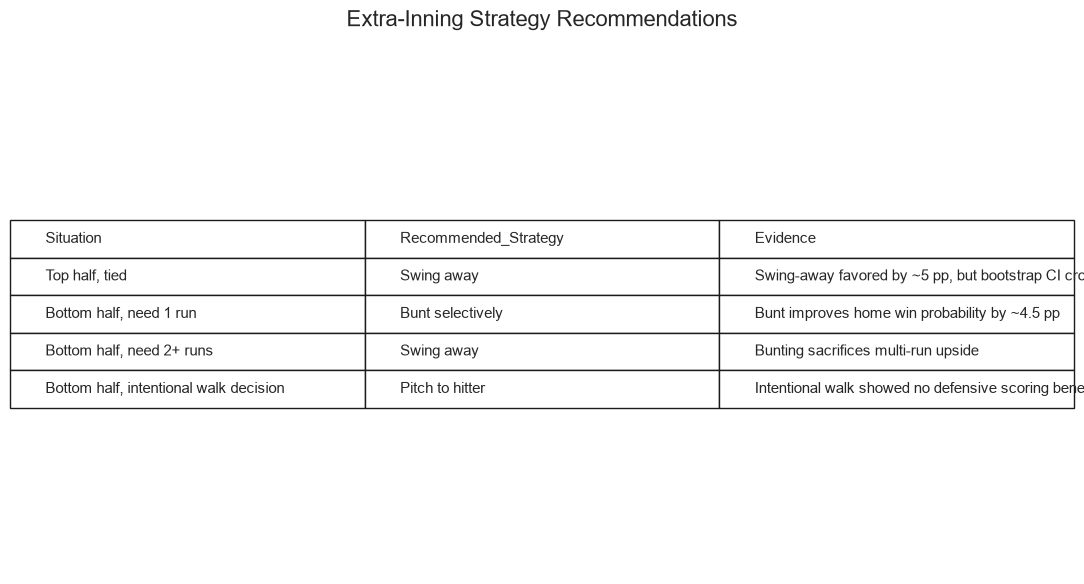

In [165]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 6))

ax.axis("off")

table = ax.table(
    cellText=strategy_chart.values,
    colLabels=strategy_chart.columns,
    cellLoc="left",
    colLoc="left",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

plt.title(
    "Extra-Inning Strategy Recommendations",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    "extra_inning_strategy_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

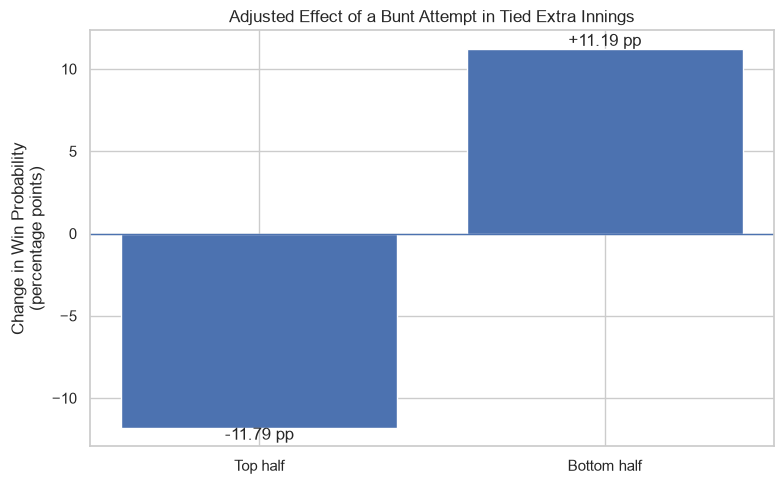

In [166]:
bunt_effects = pd.DataFrame({
    "Situation": [
        "Top half",
        "Bottom half"
    ],
    "Effect": [
        -11.79,
        11.19
    ]
})
plt.figure(figsize=(8, 5))

plt.bar(
    bunt_effects["Situation"],
    bunt_effects["Effect"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.ylabel(
    "Change in Win Probability\n(percentage points)"
)

plt.title(
    "Adjusted Effect of a Bunt Attempt in Tied Extra Innings"
)

plt.text(
    0,
    -11.79,
    "-11.79 pp",
    ha="center",
    va="top"
)

plt.text(
    1,
    11.19,
    "+11.19 pp",
    ha="center",
    va="bottom"
)

plt.tight_layout()

plt.savefig(
    "bunt_win_probability_effect.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

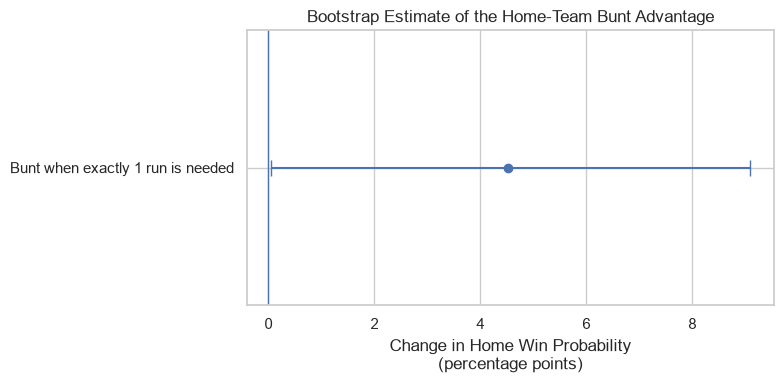

In [167]:
home_effect = 4.52
lower = 0.05
upper = 9.09

plt.figure(figsize=(8, 4))

plt.errorbar(
    x=home_effect,
    y=0,
    xerr=[
        [home_effect - lower],
        [upper - home_effect]
    ],
    fmt="o",
    capsize=6
)

plt.axvline(
    0,
    linewidth=1
)

plt.yticks(
    [0],
    ["Bunt when exactly 1 run is needed"]
)

plt.xlabel(
    "Change in Home Win Probability\n(percentage points)"
)

plt.title(
    "Bootstrap Estimate of the Home-Team Bunt Advantage"
)

plt.tight_layout()

plt.savefig(
    "home_bunt_bootstrap_ci.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

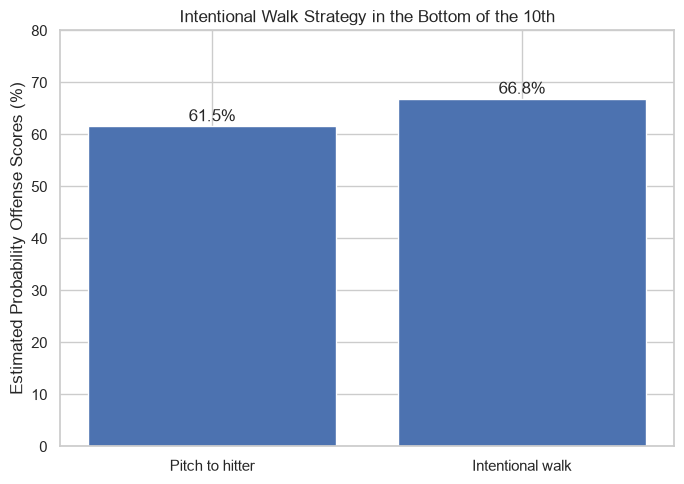

In [168]:
iwalk_plot = pd.DataFrame({
    "Strategy": [
        "Pitch to hitter",
        "Intentional walk"
    ],
    "Scoring_Probability": [
        61.55,
        66.84
    ]
})
plt.figure(figsize=(7, 5))

plt.bar(
    iwalk_plot["Strategy"],
    iwalk_plot["Scoring_Probability"]
)

plt.ylabel(
    "Estimated Probability Offense Scores (%)"
)

plt.title(
    "Intentional Walk Strategy in the Bottom of the 10th"
)

plt.ylim(0, 80)

for i, value in enumerate(
    iwalk_plot["Scoring_Probability"]
):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "intentional_walk_scoring_probability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()